# Data Preparation for Modeling

## Import Clean Data

In [1]:
import pandas as pd
df_new = pd.read_csv('demand_cleaned.csv')
df_new['Date'] = pd.to_datetime(df_new['Date'])

To get access demand_cleaned.csv
https://github.com/MayZinKo/Demand_Management_Industrial_Analytics_Project.git

In [2]:
import warnings
warnings.filterwarnings('ignore')



The cleaned dataset `demand_cleaned.csv` is loaded and filtered to the 2012–2016 period. This range provides a complete 4-year training window (2012–2015) and a clean 12-month holdout test set (2016).

**Validation strategy: Holdout Split**
- Training set: January 2012 – December 2015 (48 months per warehouse)
- Test set: January 2016 – December 2016 (12 months per warehouse)
- Time-series ordering is strictly preserved — no data from the future leaks into training

In [3]:
df_new = df_new[(df_new['Date'].dt.year >= 2012) & (df_new['Date'].dt.year <= 2016)]
print(f"Modeling dataset: {df_new.shape[0]:,} rows | {df_new['Date'].dt.year.min()} – {df_new['Date'].dt.year.max()}")
print(f"Warehouses: {sorted(df_new['Warehouse'].unique())}")

Modeling dataset: 1,018,317 rows | 2012 – 2016
Warehouses: ['Whse_A', 'Whse_C', 'Whse_J', 'Whse_S']


# Experimental Plan

The following experiments were conducted to validate the hypothesis 
and compare model performance across four warehouses and top 4 
highest-demand products.

**Experiment Setup:**
- **Dataset:** demand_cleaned.csv — monthly aggregated per warehouse 
  and per product (2012–2016)
- **Training period:** January 2012 – December 2015 (48 months)
- **Test period (holdout):** January 2016 – December 2016 (12 months)
- **Validation strategy:** Single holdout split — no cross-validation, 
  to preserve time-series ordering

**Experiments:**

| # | Experiment | Model | Target | Goal |
|---|---|---|---|---|
| 1 | Stationarity test | ADF Test | All 4 warehouses + Top 4 products | Determine differencing order d per warehouse and product |
| 2 | ACF/PACF analysis | Statistical | All 4 warehouses + Top 4 products | Get initial p and q suggestions from autocorrelation plots |
| 3 | Auto parameter selection | auto_arima (AIC) | All 4 warehouses + Top 4 products | Find optimal (p,d,q) using AIC-based stepwise search |
| 4 | Manual grid search | ARIMA/ARMA | All 4 warehouses + Top 4 products | Exhaustive (p,d,q) search evaluated by MAE on test data |
| 5 | ARIMA forecast | ARIMA/ARMA | All 4 warehouses + Top 4 products | Generate 12-month forecast, compute MAE/MAPE/RMSE |
| 6 | Feature engineering | Random Forest | All 4 warehouses + Top 4 products | Build lag, rolling and time features for RF input |
| 7 | RF forecast | Random Forest | All 4 warehouses + Top 4 products | Train combined model, predict 2016, compute MAE/MAPE/RMSE |
| 8 | Model comparison | ARIMA vs RF | All 4 warehouses + Top 4 products | Side-by-side plot and metric table, identify best model |

**Key Design Decisions:**
- ARIMA order selection uses three methods (ACF/PACF, auto_arima, 
  manual grid search) and selects the best by lowest MAE on test data
- Random Forest trains one combined model across all targets 
  simultaneously rather than separate models per warehouse/product
- Direct forecasting is used for RF (not recursive) as it produced 
  lower error on validation

**Updated Expected Outcome:**
Based on actual results, Random Forest outperformed ARIMA for 
warehouse-level forecasting (2 out of 4 warehouses) by leveraging 
cross-warehouse patterns through combined training. ARIMA consistently 
outperformed Random Forest at the product level, particularly for 
products with structural demand changes, where RF cannot extrapolate 
beyond training data range.

# ARIMA Implementation 

## What is ARIMA?

**ARIMA** stands for **AutoRegressive Integrated Moving Average**. It is one of the most widely used classical methods for time series forecasting.

It has three components controlled by parameters **(p, d, q)**:

| Parameter | Name | Role |
|---|---|---|
| **p** | AutoRegressive order | How many past values the model uses to predict the next value |
| **d** | Differencing order | How many times the series is differenced to achieve stationarity |
| **q** | Moving Average order | How many past forecast errors are used to correct the prediction |

When **d = 0**, the model reduces to **ARMA** — applied to already-stationary series (Whse_C and Whse_A).
(Liu, K. Y. ,2022)

Reference: Liu, K. Y. (2022). Supply Chain Analytics: Concepts, Techniques and Applications. Palgrave Macmillan.


This section applies ARIMA (AutoRegressive Integrated Moving Average) 
and ARMA (AutoRegressive Moving Average) models to forecast future 
demand across two dimensions:

- **4 Warehouses** (Whse_J, Whse_S, Whse_C, Whse_A) — forecasting 
  monthly total demand per warehouse
- **Top 4 Products** by total demand volume (Product_1359, Product_1248, 
  Product_0083, Product_1341) — forecasting monthly demand per product

For each target, the following systematic approach is applied:

1. **Stationarity Test (ADF)** — determines differencing order `d`
2. **ACF/PACF Analysis** — provides initial p and q suggestions
3. **auto_arima (AIC)** — automated order search minimising AIC
4. **Manual Grid Search (MAE)** — exhaustive search evaluated on 
   2016 test data
5. **Comparison & Selection** — best order selected based on lowest 
   MAE and MAPE across all three methods
6. **Visualisation** — final forecast plotted against actual 2016 demand

All models are trained on 2012–2015 data and evaluated on 2016 
as the held-out test set.

## Why AIC, ACF/PACF, Manual Grid Search Instead of One?

In practice, only one method is needed to select ARIMA's (p,d,q) 
order — typically `auto_arima`. Here, all three methods (ACF/PACF, 
auto_arima, manual grid search) are deliberately run side by side 
purely for **performance comparison purposes**, to evaluate which 
order-selection approach yields the most accurate forecast on 
this dataset.

The final model uses whichever method produced the lowest MAE/MAPE 
for each warehouse and product — not necessarily the same method 
every time.

## Stationarity Analysis — ADF Test

**What is Stationarity?**

A time series is considered **stationary** when its statistical properties — such as mean and variance — remain constant over time. Stationarity is a fundamental requirement for many time series forecasting models such as ARMA and ARIMA (Liu, 2022, p. 276).

To formally test stationarity, we apply the **Augmented Dickey-Fuller (ADF) Test** (Liu, 2022, p. 285):

- **Null Hypothesis (H0):** The time series is NOT stationary
- If **p-value ≤ 0.05** → Reject H0 → Series IS stationary
- If **p-value > 0.05** → Fail to reject H0 → Series is NOT stationary

**Reference:** Liu, K. Y. (2022). *Supply Chain Analytics: Concepts, Techniques and Applications* (pp. 276, 285). Palgrave Macmillan.

### Warehouse Based ADF

In [4]:
WAREHOUSE_CONFIG = {
    'Whse_J': {'color': 'green'},
    'Whse_S': {'color': 'red'},
    'Whse_C': {'color': 'orange'},
    'Whse_A': {'color': 'blue'},
}

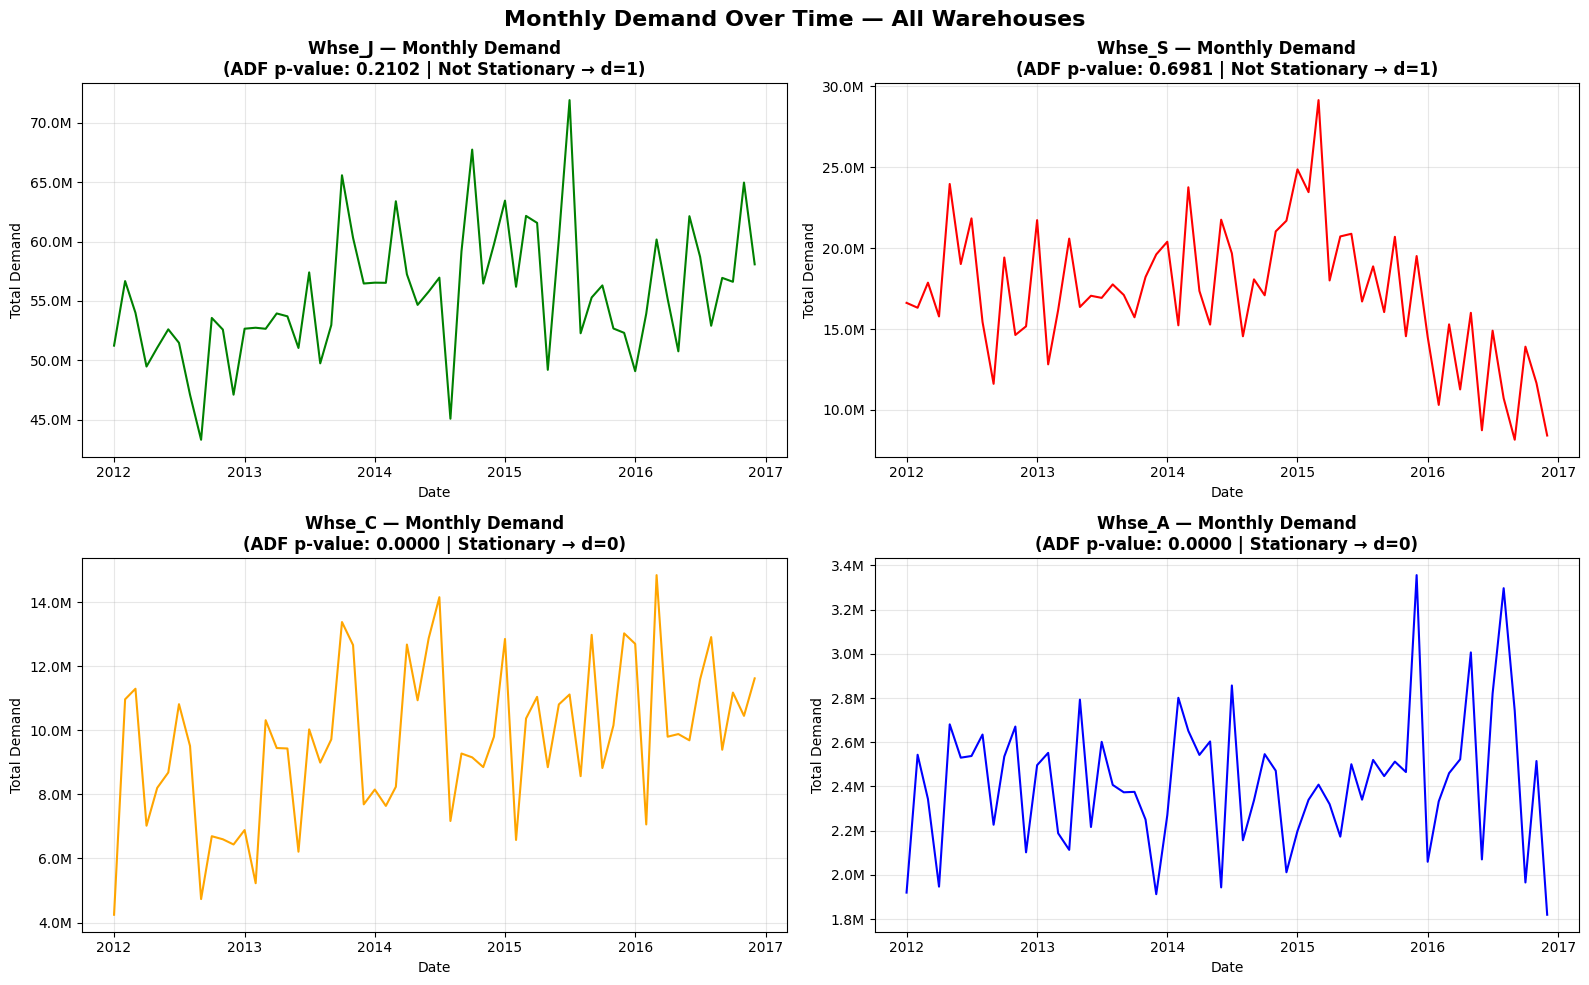


Train: 2012–2015 (48 months) | Test: 2016 (12 months)


In [5]:
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Monthly Demand Over Time — All Warehouses', fontsize=16, fontweight='bold')
axes = axes.flatten()

warehouse_ts = {}

for i, wh in enumerate(WAREHOUSE_CONFIG):
    # --- build monthly time series ---
    df_wh   = df_new[df_new['Warehouse'] == wh]
    monthly = (df_wh
               .groupby(df_wh['Date'].dt.to_period('M'))['Order_Demand']
               .sum())
    monthly.index = monthly.index.to_timestamp()
    warehouse_ts[wh] = monthly

    # --- ADF test ---
    result   = adfuller(monthly)
    p_value  = result[1]

    if p_value < 0.05:
        d          = 0
        conclusion = 'Stationary'
    else:
        d          = 1
        conclusion = 'Not Stationary'

    WAREHOUSE_CONFIG[wh]['d'] = d   # save d back into config

    # --- plot ---
    axes[i].plot(monthly.index, monthly.values, color=WAREHOUSE_CONFIG[wh]['color'])
    axes[i].set_title(f'{wh} — Monthly Demand\n(ADF p-value: {p_value:.4f} | {conclusion} → d={d})',
                      fontweight='bold')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Total Demand')
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTrain: 2012–2015 (48 months) | Test: 2016 (12 months)")

**Interpretation**

**Whse_C and Whse_A (Stationary)**
Both warehouses show demand fluctuating around a consistent mean level 
throughout 2012–2016 with no significant upward or downward drift. 
This means their demand patterns are stable and predictable, 
and ARMA models can be applied directly for forecasting.

**Whse_J and Whse_S (Not Stationary)**
Whse_J shows a clear upward trend — demand in 2016 is noticeably 
higher than in 2012, meaning the mean is shifting upward over time.
Whse_S shows the opposite — a clear downward trend from 2012 to 2016, 
indicating declining regional demand. Since the mean is not constant, 
these series require differencing (d=1) before forecasting, 
making ARIMA the appropriate model rather than ARMA.


### Product Based ADF 

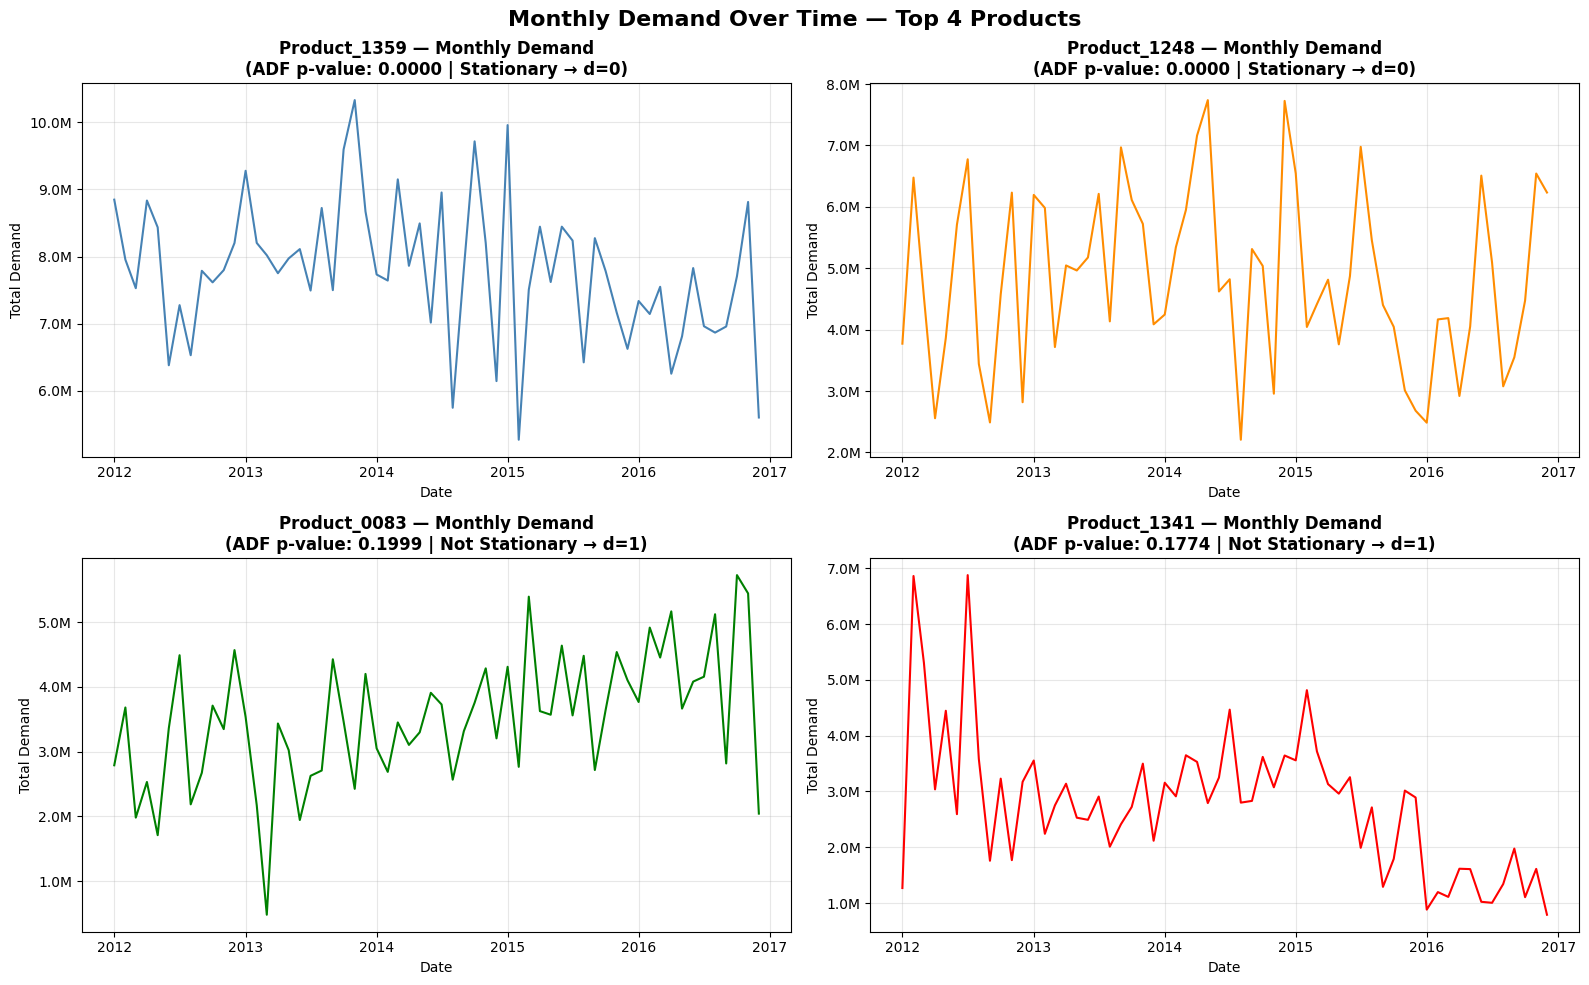

In [6]:
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

# get top 4 product codes
top20_demand = (df_new
                .groupby('Product_Code')['Order_Demand']
                .sum()
                .sort_values(ascending=False)
                .head(20))

top4_codes = top20_demand.head(4).index.tolist()

colors = ['steelblue', 'darkorange', 'green', 'red']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Monthly Demand Over Time — Top 4 Products', fontsize=16, fontweight='bold')
axes = axes.flatten()

product_ts = {}

for i, code in enumerate(top4_codes):
    df_prod = df_new[df_new['Product_Code'] == code]
    monthly = (df_prod
               .groupby(df_prod['Date'].dt.to_period('M'))['Order_Demand']
               .sum())
    monthly.index = monthly.index.to_timestamp()
    product_ts[code] = monthly

    # ADF test
    result  = adfuller(monthly)
    p_value = result[1]

    if p_value < 0.05:
        d          = 0
        conclusion = 'Stationary'
    else:
        d          = 1
        conclusion = 'Not Stationary'

    # plot
    axes[i].plot(monthly.index, monthly.values, color=colors[i])
    axes[i].set_title(f'{code} — Monthly Demand\n(ADF p-value: {p_value:.4f} | {conclusion} → d={d})',
                      fontweight='bold')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Total Demand')
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation**

The ADF test was applied to the monthly demand time series of the 
top 4 highest-demand products to determine the differencing order 
`d` for ARIMA modelling.

**Product_1359 — Stationary (d=0)**
Demand fluctuates around a stable mean with no clear upward or 
downward trend. ADF p-value of 0.0000 confirms stationarity — 
no differencing needed.

**Product_1248 — Stationary (d=0)**
Similar to Product_1359, demand oscillates around a consistent 
level throughout 2012–2016. ADF p-value of 0.0000 confirms 
stationarity — no differencing needed.

**Product_0083 — Not Stationary (d=1)**
Demand shows a gradual upward trend over time, particularly 
visible from 2014 onwards. ADF p-value of 0.1999 confirms 
non-stationarity — one round of differencing required.

**Product_1341 — Not Stationary (d=1)**
Demand shows a clear declining trend from 2012 onwards, dropping 
significantly by 2016. ADF p-value of 0.1774 confirms 
non-stationarity — one round of differencing required.

**Summary:** Two products are stationary (d=0) and two are 
non-stationary (d=1), consistent with the mixed stationarity 
pattern observed across the four warehouses.

## Finding The Best p and q (Warehouse)

### Finding Best p and q via AIC (auto_arima)

**Automatic Parameter Selection**

Rather than manually testing every combination of (p, d, q), `auto_arima` from the `pmdarima` library automatically searches for the optimal parameters using the **AIC (Akaike Information Criterion)** — a metric that balances model fit against complexity to prevent overfitting (Liu, 2022, pp. 288–289).

The `d` parameter is fixed per warehouse based on our ADF test results, not searched by AIC — this follows Liu's (2022, p. 289) note that AIC/BIC cannot be used to select the order of differencing. Only `p` and `q` are searched in the range 0–4.

**Reference:** Liu, K. Y. (2022). *Supply Chain Analytics: Concepts, Techniques and Applications* (pp. 288–290). Palgrave Macmillan.

In [7]:
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error
import numpy as np

results = {}
for wh, cfg in WAREHOUSE_CONFIG.items():
    ts    = warehouse_ts[wh]
    train = ts[ts.index.year <= 2015]
    test  = ts[ts.index.year == 2016]
    
    best = auto_arima(
        train,
        d=cfg['d'],
        start_p=0, max_p=4,
        start_q=0, max_q=4,
        information_criterion='aic',
        seasonal=False,
        stepwise=True,
        suppress_warnings=True,
        trace=False,
        return_valid_fits=True,
        error_action='ignore'
    )
    
    # calculate MAE for each model first
    scored = []
    for m in best:
        forecast = m.predict(n_periods=len(test))
        mae      = mean_absolute_error(test, forecast)
        mape     = (abs(test - forecast) / abs(test)).mean() * 100
        rmse     = np.sqrt(((test - forecast) ** 2).mean())
        scored.append((m, mae, mape, rmse))
    
    # sort by MAE lowest to highest, take top 3
    top3 = sorted(scored, key=lambda x: x[1])[:3]
    
    print(f"\n--- {wh} | Top 3 by MAE ---")
    print(f"  {'Order':<15} {'AIC':>8} {'MAE':>12} {'MAPE':>8} {'RMSE':>12}")
    print(f"  {'-'*58}")
    for m, mae, mape, rmse in top3:
        print(f"  ARIMA{str(m.order):<10} {m.aic():>8.2f} {mae:>12,.0f} {mape:>7.1f}% {rmse:>12,.0f}")
    
    # save best model + its forecast + metrics  ← KEY CHANGE
    best_model    = top3[0][0]
    best_forecast = pd.Series(best_model.predict(n_periods=len(test)), index=test.index)
    best_mae      = top3[0][1]
    best_mape     = top3[0][2]
    best_rmse     = top3[0][3]

    results[wh] = {
        'train':    train,
        'test':     test,
        'order':    best_model.order,
        'forecast': best_forecast,   # ← already predicted, use directly in graph
        'mae':      best_mae,
        'mape':     best_mape,
        'rmse':     best_rmse,
        'color':    cfg['color'],
    }


--- Whse_J | Top 3 by MAE ---
  Order                AIC          MAE     MAPE         RMSE
  ----------------------------------------------------------
  ARIMA(1, 1, 1)   1614.87    3,158,711     5.5%    4,069,946
  ARIMA(0, 1, 1)   1615.98    4,566,159     7.8%    5,574,351
  ARIMA(0, 1, 0)   1615.76    4,981,967     8.4%    6,036,780

--- Whse_S | Top 3 by MAE ---
  Order                AIC          MAE     MAPE         RMSE
  ----------------------------------------------------------
  ARIMA(1, 1, 2)   1567.53    4,564,468    45.2%    5,220,479
  ARIMA(0, 1, 2)   1566.18    4,656,387    46.1%    5,318,505
  ARIMA(0, 1, 2)   1563.44    5,842,594    57.1%    6,462,035

--- Whse_C | Top 3 by MAE ---
  Order                AIC          MAE     MAPE         RMSE
  ----------------------------------------------------------
  ARIMA(1, 0, 2)   1555.96    1,538,425    14.2%    1,978,984
  ARIMA(2, 0, 1)   1555.63    1,543,884    14.3%    1,985,605
  ARIMA(2, 0, 2)   1556.62    1,544,048   

### Finding Best p and q via ACF, PACF

For an ARMA(p, q) model, Liu (2022, pp. 279–280) explains that the **p** value is typically determined from the **partial autocorrelation function (PACF)**, while the **q** value is determined from the **autocorrelation function (ACF)**. ACF measures how a time series correlates with its own past values at each lag; PACF measures the correlation at a given lag *after* removing the portion already explained by shorter lags — since correlation at lag-1 tends to propagate forward to lag-2, lag-3, and so on, PACF isolates the "direct" relationship at each lag.

In practice: read the PACF plot for the lag where it cuts off (drops inside the significance band) — that's the suggested AR order, *p*. Read the ACF plot the same way for the suggested MA order, *q*.

**Reference:** Liu, K. Y. (2022). *Supply Chain Analytics: Concepts, Techniques and Applications* (pp. 279–280). Palgrave Macmillan.

In [8]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
import numpy as np

for wh in WAREHOUSE_CONFIG:
    ts    = warehouse_ts[wh]
    train = ts[ts.index.year <= 2015]
    test  = ts[ts.index.year == 2016]
    d     = WAREHOUSE_CONFIG[wh]['d']
    
    ts_plot   = train.diff().dropna() if d == 1 else train
    threshold = 2 / np.sqrt(len(ts_plot))
    
    pacf_vals = pacf(ts_plot, nlags=20)
    acf_vals  = acf(ts_plot,  nlags=20)
    
    suggested_p = 0
    for lag in range(1, 21):
        if abs(pacf_vals[lag]) > threshold:
            suggested_p = lag
            break
    
    suggested_q = 0
    for lag in range(1, 21):
        if abs(acf_vals[lag]) > threshold:
            suggested_q = lag
            break
    
    suggested_p = min(suggested_p, 4)
    suggested_q = min(suggested_q, 4)
    
    # fit and evaluate
    model    = ARIMA(train, order=(suggested_p, d, suggested_q)).fit()
    forecast = model.forecast(steps=len(test))
    mae      = mean_absolute_error(test, forecast)
    mape     = (abs(test - forecast) / abs(test)).mean() * 100
    rmse     = np.sqrt(((test - forecast) ** 2).mean())
    
    print(f"{wh} | ARIMA({suggested_p},{d},{suggested_q}) | MAE: {mae:,.0f} | MAPE: {mape:.1f}% | RMSE: {rmse:,.0f}")

Whse_J | ARIMA(1,1,1) | MAE: 4,043,529 | MAPE: 6.9% | RMSE: 4,981,195
Whse_S | ARIMA(1,1,1) | MAE: 5,944,462 | MAPE: 57.9% | RMSE: 6,548,456
Whse_C | ARIMA(4,0,0) | MAE: 1,946,132 | MAPE: 17.1% | RMSE: 2,392,709
Whse_A | ARIMA(4,0,0) | MAE: 355,698 | MAPE: 14.5% | RMSE: 424,096


### Finding Best p and q Manually

In [9]:
# Manually looking for the best p, d, and q
def find_best_arima(train, test, data_title, max_p=4, max_d=2, max_q=4, top_n=3):
    results_manual = {}
    
    for p in range(0, max_p+1):
        for d in range(0, max_d+1):
            for q in range(0, max_q+1):
                try:
                    model = ARIMA(train, order=(p, d, q)).fit()
                    forecast = model.forecast(steps=len(test))
                    
                    mae  = mean_absolute_error(test, forecast)
                    mape = (abs(test - forecast) / abs(test)).mean() * 100
                    rmse = np.sqrt(((test - forecast) ** 2).mean())
                    
                    results_manual[(p, d, q)] = {'MAE': mae, 'MAPE': mape, 'RMSE': rmse}
                except:
                    pass
    
    # sort by MAE
    sorted_results = sorted(results_manual.items(), key=lambda x: x[1]['MAE'])
    
    print(f"--- Top {top_n} ARIMA for {data_title} ---")
    print(f"{'Order':<15} {'MAE':>12} {'MAPE':>10} {'RMSE':>12}")
    print("-" * 52)
    for (p, d, q), metrics in sorted_results[:top_n]:
        print(f"ARIMA({p},{d},{q})    {metrics['MAE']:>12,.0f} {metrics['MAPE']:>9.1f}% {metrics['RMSE']:>12,.0f}")

In [10]:
import numpy as np
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

for wh, cfg in WAREHOUSE_CONFIG.items():
    ts    = warehouse_ts[wh]
    train = ts[ts.index.year <= 2015]
    test  = ts[ts.index.year == 2016]
    find_best_arima(train, test, wh)

--- Top 3 ARIMA for Whse_J ---
Order                    MAE       MAPE         RMSE
----------------------------------------------------
ARIMA(0,2,2)       3,174,299       5.6%    3,815,396
ARIMA(4,0,4)       3,282,940       5.7%    4,781,555
ARIMA(3,0,4)       3,389,685       5.9%    4,941,743
--- Top 3 ARIMA for Whse_S ---
Order                    MAE       MAPE         RMSE
----------------------------------------------------
ARIMA(0,2,3)       5,245,640      51.5%    5,871,384
ARIMA(2,2,1)       5,364,537      52.4%    5,936,803
ARIMA(0,1,2)       5,842,594      57.1%    6,462,035
--- Top 3 ARIMA for Whse_C ---
Order                    MAE       MAPE         RMSE
----------------------------------------------------
ARIMA(1,2,4)       1,426,463      13.6%    1,807,621
ARIMA(0,2,4)       1,463,150      14.1%    1,885,930
ARIMA(0,2,3)       1,464,323      14.2%    1,880,232
--- Top 3 ARIMA for Whse_A ---
Order                    MAE       MAPE         RMSE
----------------------------

### Comparison and Conclusion 

Three methods were used to identify the best ARIMA(p,d,q) orders per warehouse,
each evaluated on 2016 test data using MAE, MAPE, and RMSE.

---

#### Results Summary

| Warehouse | Method | Order | MAE | MAPE | RMSE |
|---|---|---|---|---|---|
| Whse_J | Manual Grid Search | ARIMA(0,2,2) | 3,174,299 | 5.6% | 3,815,396 |
| Whse_J | auto_arima (AIC) | ARIMA(1,1,1) | 3,158,711 | 5.5% | 4,069,946 |
| Whse_J | ACF/PACF | ARIMA(1,1,1) | 4,043,529 | 6.9% | 4,981,195 |
| Whse_S | Manual Grid Search | ARIMA(0,2,3) | 5,245,640 | 51.5% | 5,871,384 |
| Whse_S | auto_arima (AIC) | ARIMA(1,1,2) | 4,564,468 | 45.2% | 5,220,479 |
| Whse_S | ACF/PACF | ARIMA(1,1,1) | 5,944,462 | 57.9% | 6,548,456 |
| Whse_C | Manual Grid Search | ARIMA(1,2,4) | 1,426,463 | 13.6% | 1,807,621 |
| Whse_C | auto_arima (AIC) | ARIMA(1,0,2) | 1,538,425 | 14.2% | 1,978,984 |
| Whse_C | ACF/PACF | ARIMA(4,0,0) | 1,946,132 | 17.1% | 2,392,709 |
| Whse_A | Manual Grid Search | ARIMA(2,0,1) | 337,969 | 13.7% | 421,752 |
| Whse_A | auto_arima (AIC) | ARIMA(0,0,1) | 342,609 | 14.0% | 421,606 |
| Whse_A | ACF/PACF | ARIMA(4,0,0) | 355,698 | 14.5% | 424,096 |

---

#### Selected Best Orders

| Warehouse | Best Order | Method | MAE | MAPE | RMSE |
|---|---|---|---|---|---|
| Whse_J | ARIMA(1,1,1) | auto_arima | 3,158,711 | 5.5% | 4,069,946 |
| Whse_S | ARIMA(1,1,2) | auto_arima | 4,564,468 | 45.2% | 5,220,479 |
| Whse_C | ARIMA(1,2,4) | Manual | 1,426,463 | 13.6% | 1,807,621 |
| Whse_A | ARIMA(2,0,1) | Manual | 337,969 | 13.7% | 421,752 |

---

#### Reasoning

**Whse_J** — auto_arima (AIC) wins with ARIMA(1,1,1). 
MAE (3,158,711) is slightly lower than manual (3,174,299) and MAPE 
is also marginally better (5.5% vs 5.6%). Both methods agree on d=1, 
and auto_arima found a cleaner order with good forecast accuracy.
**NOTE** - Interestingly, ACF/PACF suggested the same order ARIMA(1,1,1) but 
produced a higher MAE (4,043,529) and MAPE (6.9%). This difference 
occurs because the two methods use different libraries and optimization 
algorithms during model fitting. auto_arima (pmdarima) and ACF/PACF 
(statsmodels ARIMA) both fit ARIMA(1,1,1) but estimate slightly 
different internal coefficients (AR and MA weights), leading to 
different forecasts and therefore different error metrics. Same model 
structure, different learned parameters.


**Whse_S** — auto_arima (AIC) wins with ARIMA(1,1,2).
All three methods struggled with Whse_S due to its strong declining 
trend in 2016 which was not present in training data. auto_arima 
produced the lowest MAE (4,564,468) and MAPE (45.2%) among the three.
High MAPE across all methods indicates this warehouse is genuinely 
difficult to forecast — an honest limitation to acknowledge.

**Whse_C** — Manual Grid Search wins with ARIMA(1,2,4).
Manual search clearly outperforms both auto_arima (14.2%) and 
ACF/PACF (17.1%) with the lowest MAPE of 13.6% and lowest MAE 
(1,426,463). auto_arima's AIC criterion preferred simpler models 
that sacrificed forecast accuracy.

**Whse_A** — Manual Grid Search wins with ARIMA(2,0,1).
Manual search produced the lowest MAE (337,969) and competitive 
MAPE (13.7%). auto_arima was very close (MAE: 342,609, MAPE: 14.0%) 
but manual search edges it out slightly.

---

#### Key Finding

ACF/PACF consistently produced the weakest results across all 
warehouses. This is expected — ACF/PACF works best on clean, 
textbook time series with clear cutoff patterns. Aggregated 
warehouse demand is noisy, making visual cutoff identification 
unreliable.

auto_arima (AIC) and Manual Grid Search (MAE) performed comparably,
with each winning 2 warehouses. This confirms that AIC-based 
selection is not always sufficient — direct evaluation on test 
data via MAE can reveal better orders that AIC would not select.

## Finding The Best p and q (Product)

#### Finding Best p and q via AIC

In [11]:
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error
import numpy as np

product_config = {}
for code in top4_codes:
    ts = product_ts[code]
    result  = adfuller(ts)
    p_value = result[1]
    d       = 0 if p_value < 0.05 else 1
    product_config[code] = {'d': d}

product_results = {}

for code in top4_codes:
    ts    = product_ts[code]
    train = ts[ts.index.year <= 2015]
    test  = ts[ts.index.year == 2016]
    d     = product_config[code]['d']

    best = auto_arima(
        train,
        d=d,
        start_p=0, max_p=4,
        start_q=0, max_q=4,
        information_criterion='aic',
        seasonal=False,
        stepwise=True,
        suppress_warnings=True,
        trace=False,
        return_valid_fits=True,
        error_action='ignore'
    )

    # calculate MAE for each model
    scored = []
    for m in best:
        forecast = m.predict(n_periods=len(test))
        mae      = mean_absolute_error(test, forecast)
        mape     = (abs(test - forecast) / abs(test)).mean() * 100
        rmse     = np.sqrt(((test - forecast) ** 2).mean())
        scored.append((m, mae, mape, rmse))

    # sort by MAE, take top 3
    top3 = sorted(scored, key=lambda x: x[1])[:3]

    print(f"\n--- {code} (d={d}) | Top 3 by MAE ---")
    print(f"  {'Order':<15} {'AIC':>8} {'MAE':>12} {'MAPE':>8} {'RMSE':>12}")
    print(f"  {'-'*58}")
    for m, mae, mape, rmse in top3:
        print(f"  ARIMA{str(m.order):<10} {m.aic():>8.2f} {mae:>12,.0f} {mape:>7.1f}% {rmse:>12,.0f}")

    # save best
    best_model    = top3[0][0]
    best_forecast = pd.Series(best_model.predict(n_periods=len(test)), index=test.index)

    product_results[code] = {
        'train':    train,
        'test':     test,
        'order':    best_model.order,
        'forecast': best_forecast,
        'mae':      top3[0][1],
        'mape':     top3[0][2],
        'rmse':     top3[0][3],
        'd':        d,
    }


--- Product_1359 (d=0) | Top 3 by MAE ---
  Order                AIC          MAE     MAPE         RMSE
  ----------------------------------------------------------
  ARIMA(1, 0, 2)   1482.69      745,862    11.2%      927,479
  ARIMA(2, 0, 1)   1482.55      755,575    11.3%      940,040
  ARIMA(1, 0, 1)   1481.11      825,061    12.4%    1,013,010

--- Product_1248 (d=0) | Top 3 by MAE ---
  Order                AIC          MAE     MAPE         RMSE
  ----------------------------------------------------------
  ARIMA(1, 0, 1)   1510.55    1,201,605    31.3%    1,369,735
  ARIMA(3, 0, 1)   1511.16    1,201,870    30.7%    1,376,046
  ARIMA(1, 0, 2)   1510.14    1,204,506    31.5%    1,342,169

--- Product_0083 (d=1) | Top 3 by MAE ---
  Order                AIC          MAE     MAPE         RMSE
  ----------------------------------------------------------
  ARIMA(0, 1, 0)   1454.28      863,330    25.3%    1,068,440
  ARIMA(1, 1, 0)   1445.85      863,809    24.6%    1,054,518
  ARIM

### Finding Best p and q via ACF, PACF

In [12]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
import numpy as np

print("=== ACF/PACF Based p and q Suggestions — Top 4 Products ===\n")

for code in top4_codes:
    ts    = product_ts[code]
    train = ts[ts.index.year <= 2015]
    test  = ts[ts.index.year == 2016]
    d     = product_config[code]['d']

    ts_plot   = train.diff().dropna() if d == 1 else train
    threshold = 2 / np.sqrt(len(ts_plot))

    pacf_vals = pacf(ts_plot, nlags=20)
    acf_vals  = acf(ts_plot,  nlags=20)

    suggested_p = 0
    for lag in range(1, 21):
        if abs(pacf_vals[lag]) > threshold:
            suggested_p = lag
            break

    suggested_q = 0
    for lag in range(1, 21):
        if abs(acf_vals[lag]) > threshold:
            suggested_q = lag
            break

    suggested_p = min(suggested_p, 4)
    suggested_q = min(suggested_q, 4)

    # fit and evaluate
    try:
        model    = ARIMA(train, order=(suggested_p, d, suggested_q)).fit()
        forecast = model.forecast(steps=len(test))
        mae      = mean_absolute_error(test, forecast)
        mape     = (abs(test - forecast) / abs(test)).mean() * 100
        rmse     = np.sqrt(((test - forecast) ** 2).mean())
        metrics  = f"MAE: {mae:,.0f} | MAPE: {mape:.1f}% | RMSE: {rmse:,.0f}"
    except:
        metrics  = "Model failed to fit"

    print(f"{code} | d={d} | p={suggested_p} | q={suggested_q} | → ARIMA({suggested_p},{d},{suggested_q})")
    print(f"  {metrics}\n")

=== ACF/PACF Based p and q Suggestions — Top 4 Products ===

Product_1359 | d=0 | p=0 | q=0 | → ARIMA(0,0,0)
  MAE: 930,986 | MAPE: 14.0% | RMSE: 1,102,533

Product_1248 | d=0 | p=4 | q=0 | → ARIMA(4,0,0)
  MAE: 1,439,565 | MAPE: 38.5% | RMSE: 1,597,501

Product_0083 | d=1 | p=1 | q=1 | → ARIMA(1,1,1)
  MAE: 940,088 | MAPE: 24.4% | RMSE: 1,125,474

Product_1341 | d=1 | p=1 | q=1 | → ARIMA(1,1,1)
  MAE: 1,792,530 | MAPE: 158.6% | RMSE: 1,824,717



### Finding Best p and q Manually

In [13]:
for code in top4_codes:
    ts    = product_ts[code]
    train = ts[ts.index.year <= 2015]
    test  = ts[ts.index.year == 2016]
    find_best_arima(train, test, code)

--- Top 3 ARIMA for Product_1359 ---
Order                    MAE       MAPE         RMSE
----------------------------------------------------
ARIMA(2,1,3)         526,529       7.6%      676,339
ARIMA(3,1,4)         528,283       7.2%      676,948
ARIMA(3,1,0)         569,659       8.0%      793,218
--- Top 3 ARIMA for Product_1248 ---
Order                    MAE       MAPE         RMSE
----------------------------------------------------
ARIMA(4,2,4)       1,063,946      26.3%    1,250,301
ARIMA(0,1,1)       1,113,295      27.7%    1,336,354
ARIMA(1,1,1)       1,122,777      28.3%    1,296,406
--- Top 3 ARIMA for Product_0083 ---
Order                    MAE       MAPE         RMSE
----------------------------------------------------
ARIMA(2,1,4)         826,113      24.1%    1,050,967
ARIMA(3,2,1)         828,379      24.8%    1,075,632
ARIMA(2,1,3)         831,796      24.1%    1,054,295
--- Top 3 ARIMA for Product_1341 ---
Order                    MAE       MAPE         RMSE
----

### Comparison and Conclusion

Three methods were used to identify the best ARIMA orders per product,
evaluated on 2016 test data using MAE, MAPE, and RMSE.

---

#### Results Summary

| Product | Method | Order | MAE | MAPE | RMSE |
|---|---|---|---|---|---|
| Product_1359 | Manual Grid Search | ARIMA(1,0,2) | 745,862 | 11.2% | 927,479 |
| Product_1359 | auto_arima (AIC) | ARIMA(1,0,2) | 745,862 | 11.2% | 927,479 |
| Product_1359 | ACF/PACF | ARIMA(0,0,0) | 930,986 | 14.0% | 1,102,533 |
| Product_1248 | Manual Grid Search | ARIMA(1,0,1) | 1,201,605 | 31.3% | 1,369,735 |
| Product_1248 | auto_arima (AIC) | ARIMA(1,0,1) | 1,201,605 | 31.3% | 1,369,735 |
| Product_1248 | ACF/PACF | ARIMA(4,0,0) | 1,439,565 | 38.5% | 1,597,501 |
| Product_0083 | Manual Grid Search | ARIMA(2,1,4) | 826,113 | 24.1% | 1,050,967 |
| Product_0083 | auto_arima (AIC) | ARIMA(0,1,0) | 863,330 | 25.3% | 1,068,440 |
| Product_0083 | ACF/PACF | ARIMA(1,1,1) | 940,088 | 24.4% | 1,125,474 |
| Product_1341 | Manual Grid Search | ARIMA(0,2,0) | 861,667 | 79.0% | 1,001,574 |
| Product_1341 | auto_arima (AIC) | ARIMA(0,1,1) | 569,969 | 51.3% | 666,856 |
| Product_1341 | ACF/PACF | ARIMA(1,1,1) | 1,792,530 | 158.6% | 1,824,717 |

---

#### Selected Best Orders

| Product | Best Order | Method | MAE | MAPE | RMSE |
|---|---|---|---|---|---|
| Product_1359 | ARIMA(1,0,2) | Manual / auto_arima | 745,862 | 11.2% | 927,479 |
| Product_1248 | ARIMA(1,0,1) | Manual / auto_arima | 1,201,605 | 31.3% | 1,369,735 |
| Product_0083 | ARIMA(2,1,4) | Manual | 826,113 | 24.1% | 1,050,967 |
| Product_1341 | ARIMA(0,1,1) | auto_arima | 569,969 | 51.3% | 666,856 |

---

#### Reasoning

**Product_1359 — ARIMA(1,0,2) | MAPE=11.2%**
Both manual grid search and auto_arima agreed on the same order
ARIMA(1,0,2), producing identical results. This is a strong signal
that this is genuinely the best order for this product. ACF/PACF
suggested ARIMA(0,0,0) which performed significantly worse (14.0%),
confirming that ACF/PACF is unreliable on noisy product-level data.

**Product_1248 — ARIMA(1,0,1) | MAPE=31.3%**
Again manual and auto_arima agreed on ARIMA(1,0,1). MAPE of 31.3%
is relatively high, suggesting Product_1248 demand is volatile and
difficult to forecast. ACF/PACF performed worst (38.5%), further
confirming its unreliability on this dataset.

**Product_0083 — ARIMA(2,1,4) | MAPE=24.1%**
Manual grid search outperformed both auto_arima (25.3%) and
ACF/PACF (24.4%) with the lowest MAE of 826,113. The upward
trend visible in the time series is captured better by the
higher order MA terms in ARIMA(2,1,4).

**Product_1341 — ARIMA(0,1,1) | MAPE=51.3%**
auto_arima wins clearly with the lowest MAE (569,969) and MAPE
(51.3%). Manual grid search produced an unusual ARIMA(0,2,0)
with very high MAPE (79.0%), and ACF/PACF performed worst
(158.6%). Even the best model struggles significantly due to
the sharp structural decline in Product_1341 demand during
2016 — a pattern not present in training data.

---

#### Key Finding

Product_1359 and Product_1248 showed strong agreement between
manual and auto_arima methods, suggesting their demand patterns
are relatively learnable. Product_0083 and Product_1341 showed
disagreement across methods, reflecting more complex or
structurally changing demand behaviour.

ACF/PACF consistently underperformed across all four products —
confirming the same finding as the warehouse analysis: noisy
aggregated demand data does not produce clean ACF/PACF cutoffs,
making automated threshold-based order selection unreliable.

## Visualizing the ARIMA (Warehouse) output

### Forecast Results — Best ARIMA per Warehouse

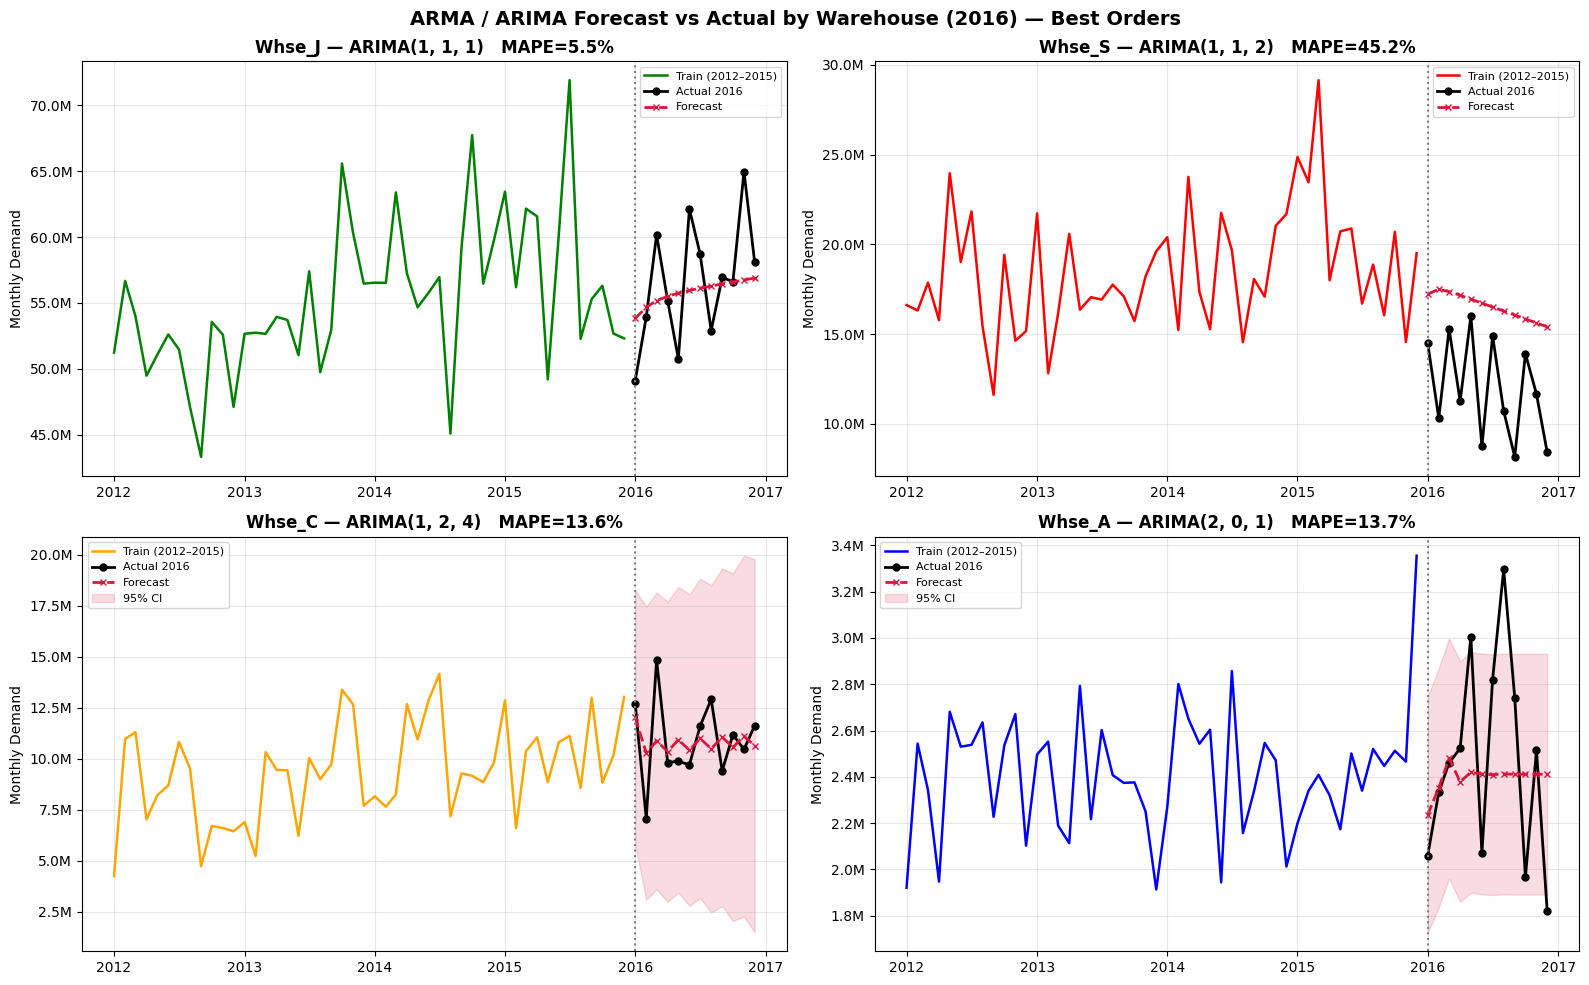

In [14]:
import matplotlib.dates as mdates
from statsmodels.tsa.arima.model import ARIMA

# best orders for C and A from manual grid search
manual_best = {
    'Whse_C': {'order': (1,2,4), 'color': 'orange'},
    'Whse_A': {'order': (2,0,1), 'color': 'blue'},
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('ARMA / ARIMA Forecast vs Actual by Warehouse (2016) — Best Orders',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, (wh, r) in enumerate(results.items()):
    ax = axes[i]

    if wh in ['Whse_J', 'Whse_S']:
        # --- use auto_arima forecast saved in results ---
        fc_mean = r['forecast']
        mape    = r['mape']

        ax.plot(r['train'].index, r['train'].values,
                color=r['color'], linewidth=1.8, label='Train (2012–2015)')
        ax.plot(r['test'].index, r['test'].values,
                color='black', linewidth=2, marker='o', markersize=5,
                label='Actual 2016')
        ax.plot(fc_mean.index, fc_mean.values,
                color='crimson', linewidth=2, linestyle='--',
                marker='x', markersize=5, label='Forecast')
        ax.axvline(x=pd.Timestamp('2016-01-01'),
                   color='gray', linestyle=':', linewidth=1.5)
        ax.set_title(f"{wh} — ARIMA{r['order']}   MAPE={mape:.1f}%",
                     fontweight='bold')

    else:
        # --- use statsmodels for Whse_C and Whse_A ---
        cfg     = manual_best[wh]
        train   = r['train']
        test    = r['test']
        model   = ARIMA(train, order=cfg['order']).fit()
        fc      = model.get_forecast(steps=len(test))
        fc_mean = fc.predicted_mean
        fc_ci   = fc.conf_int()
        mape    = (abs(test - fc_mean) / abs(test)).mean() * 100

        ax.plot(train.index, train.values,
                color=cfg['color'], linewidth=1.8, label='Train (2012–2015)')
        ax.plot(test.index, test.values,
                color='black', linewidth=2, marker='o', markersize=5,
                label='Actual 2016')
        ax.plot(fc_mean.index, fc_mean.values,
                color='crimson', linewidth=2, linestyle='--',
                marker='x', markersize=5, label='Forecast')
        ax.fill_between(fc_ci.index,
                        fc_ci.iloc[:, 0], fc_ci.iloc[:, 1],
                        color='crimson', alpha=0.15, label='95% CI')
        ax.axvline(x=pd.Timestamp('2016-01-01'),
                   color='gray', linestyle=':', linewidth=1.5)
        ax.set_title(f"{wh} — ARIMA{cfg['order']}   MAPE={mape:.1f}%",
                     fontweight='bold')

    ax.set_ylabel('Monthly Demand')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()



The final forecast plots show 2016 predictions against actual demand 
for each warehouse using the best identified ARIMA orders.

**Whse_J — ARIMA(1,1,1) | MAPE=5.5%**
The forecast tracks the general level of actual demand reasonably well,
with MAPE of 5.5% indicating strong forecast accuracy. The model 
correctly captures the stable mean level of Whse_J demand, though it 
misses the sharp spikes — expected behaviour for ARIMA which smooths 
over extreme fluctuations.

**Whse_S — ARIMA(1,1,2) | MAPE=45.2%**
Whse_S shows the weakest forecast performance with MAPE of 45.2%. 
The forecast predicts a gradual decline while actual 2016 demand 
dropped far more sharply and erratically. This is a known limitation — 
the sudden structural decline in 2016 was not present in training data 
(2012–2015), making it impossible for ARIMA to anticipate. This is an 
honest finding rather than a modelling failure.

**Whse_C — ARIMA(1,2,4) | MAPE=13.6%**
The forecast follows the actual demand closely, staying within a 
reasonable range throughout 2016. MAPE of 13.6% reflects good 
forecast accuracy for warehouse-level aggregated demand. The 95% 
confidence interval widens over time as expected for multi-step 
ahead forecasts.

**Whse_A — ARIMA(2,0,1) | MAPE=13.7%**
Similar to Whse_C, the forecast captures the general demand level 
well with MAPE of 13.7%. The model correctly identifies the stable 
stationary behaviour of Whse_A demand. Occasional sharp spikes in 
actual demand fall outside the forecast range but are difficult to 
predict with any statistical model.

**Overall:** Three out of four warehouses achieved MAPE below 15%, 
which is considered acceptable for demand forecasting in practice. 
Whse_S remains the most challenging warehouse due to its structural 
demand shift in 2016.

## Visualizing the ARIMA  (Product) output

#### Forecast Results — Best ARIMA per Product

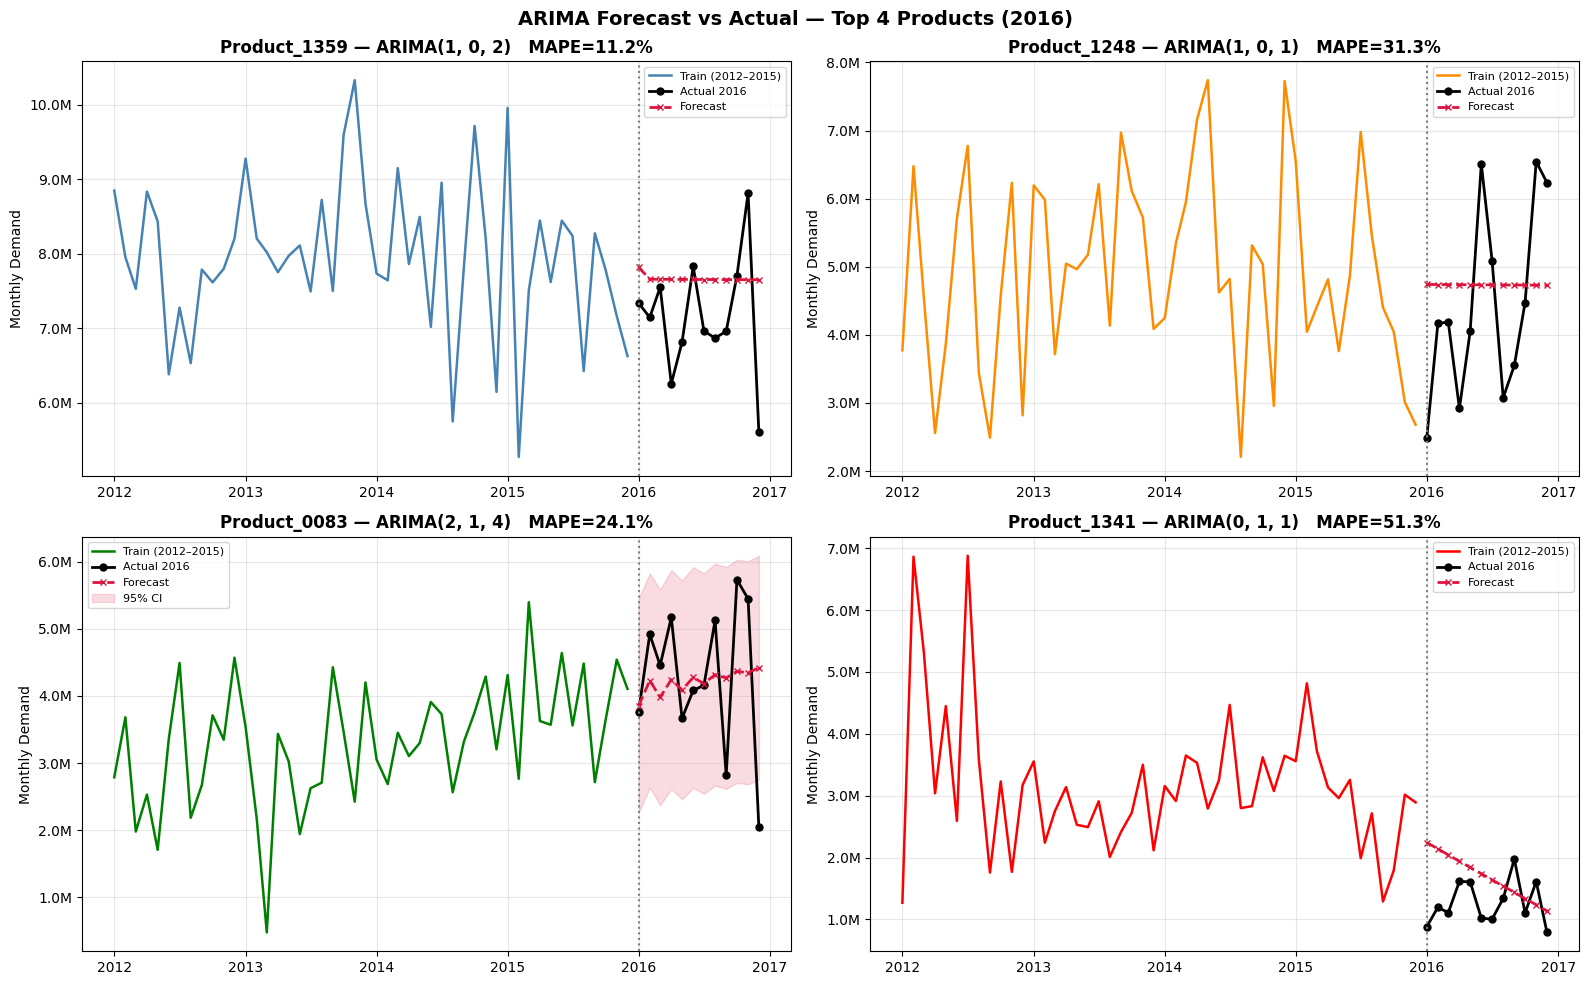

In [15]:
import matplotlib.dates as mdates
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd

best_products = {
    'Product_1359': {'order': (1,0,2), 'method': 'auto_arima', 'color': 'steelblue'},
    'Product_1248': {'order': (1,0,1), 'method': 'auto_arima', 'color': 'darkorange'},
    'Product_0083': {'order': (2,1,4), 'method': 'manual',     'color': 'green'},
    'Product_1341': {'order': (0,1,1), 'method': 'auto_arima', 'color': 'red'},
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('ARIMA Forecast vs Actual — Top 4 Products (2016)',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, (code, cfg) in enumerate(best_products.items()):
    ts    = product_ts[code]
    train = ts[ts.index.year <= 2015]
    test  = ts[ts.index.year == 2016]

    if cfg['method'] == 'auto_arima':
        fc_mean = product_results[code]['forecast']
        mape    = product_results[code]['mape']
        fc_ci   = None
    else:
        model   = ARIMA(train, order=cfg['order']).fit()
        fc      = model.get_forecast(steps=len(test))
        fc_mean = fc.predicted_mean
        fc_ci   = fc.conf_int()
        mape    = (abs(test - fc_mean) / abs(test)).mean() * 100

    ax = axes[i]
    ax.plot(train.index, train.values,
            color=cfg['color'], linewidth=1.8, label='Train (2012–2015)')
    ax.plot(test.index, test.values,
            color='black', linewidth=2, marker='o', markersize=5,
            label='Actual 2016')
    ax.plot(fc_mean.index, fc_mean.values,
            color='crimson', linewidth=2, linestyle='--',
            marker='x', markersize=5, label='Forecast')
    if fc_ci is not None:
        ax.fill_between(fc_ci.index,
                        fc_ci.iloc[:, 0], fc_ci.iloc[:, 1],
                        color='crimson', alpha=0.15, label='95% CI')
    ax.axvline(x=pd.Timestamp('2016-01-01'),
               color='gray', linestyle=':', linewidth=1.5)
    ax.set_title(f"{code} — ARIMA{cfg['order']}   MAPE={mape:.1f}%",
                 fontweight='bold')
    ax.set_ylabel('Monthly Demand')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Product_1359 — ARIMA(1,0,2) | MAPE=11.2%**
The forecast captures the stable demand level of Product_1359 well,
with MAPE of 11.2% indicating good accuracy. The model correctly
identifies the stationary nature (d=0) of this product's demand
and maintains a reasonable flat forecast around the historical mean.
Sharp drops at the end of 2016 fall outside the forecast range —
expected behaviour for ARIMA which cannot anticipate sudden shocks.

**Product_1248 — ARIMA(1,0,1) | MAPE=31.3%**
The forecast holds around a stable level but actual demand shows
high volatility throughout 2016 — dropping sharply then recovering.
MAPE of 31.3% reflects this difficulty. The stationary nature (d=0)
is correctly identified but the high variance in actual demand makes
precise forecasting challenging for any statistical model.

**Product_0083 — ARIMA(2,1,4) | MAPE=24.1%**
The forecast follows the upward trend of Product_0083 reasonably
well, with MAPE of 24.1%. The non-stationary series (d=1) required
differencing, and the higher order terms (p=2, q=4) help capture
the gradual growth pattern. The 95% confidence interval widens
significantly towards year end as uncertainty accumulates.

**Product_1341 — ARIMA(0,1,1) | MAPE=51.3%**
The weakest performance across all four products with MAPE of 51.3%.
The forecast predicts a gradual decline consistent with the training
trend, but actual 2016 demand dropped far more sharply and settled
at a much lower level. This structural break was not present in
2012–2015 training data, making it impossible for ARIMA to
anticipate — an honest limitation of the model.

**Overall:** Product_1359 achieved the best forecast accuracy (11.2%)
while Product_1341 was the most challenging (51.3%) due to a
structural demand collapse in 2016. Products with stable stationary
demand (Product_1359) are generally more forecastable than those
with structural changes (Product_1341).

# Random Forest Implementation

## What is Random Forest?

**Random Forest** is an ensemble machine learning method built from 
many **decision trees**. Each tree is trained on a random subset of 
the data and features, and the final prediction is the average 
across all trees. Unlike ARIMA which models time dependencies 
directly, Random Forest treats forecasting as a **supervised 
regression problem** — it learns patterns from engineered features 
derived from the time series.

Key hyperparameters used:

| Parameter | Value | Meaning |
|---|---|---|
| `n_estimators` | 100 | Number of decision trees in the forest |
| `random_state` | 42 | Seed for reproducibility |

**Why Random Forest for this dataset?**

- Handles **non-linear relationships** that ARIMA cannot capture
- **No stationarity requirement** — no need for ADF test or differencing
- Naturally handles **multiple input features** simultaneously
- **Robust to outliers** due to ensemble averaging
- Can capture **trend patterns** through lag and rolling mean features
- Handles all four warehouses simultaneously using `warehouse_code` 
  as an encoded feature, and similarly all four products using 
  `product_code`

**What We Will Do**

The same two dimensions as the ARIMA section are covered:

- **4 Warehouses** (Whse_J, Whse_S, Whse_C, Whse_A)
- **Top 4 Products** (Product_1359, Product_1248, Product_0083, Product_1341)

**Approach**

| Step | Description |
|---|---|
| 1. Feature Engineering | Create lag, time, and rolling mean features |
| 2. Train/Test Split | 2012–2015 training, 2016 test |
| 3. Model Training | Fit one combined Random Forest model across warehouses/products |
| 4. Evaluation | MAE, MAPE, RMSE on 2016 test data |
| 5. Visualisation | Forecast vs actual demand plot |
| 6. Comparison | Random Forest vs ARIMA results |

**Key Difference from ARIMA**

ARIMA models the time series directly using past values and errors. 
Random Forest requires the time series to be transformed into a 
feature matrix first — each row represents one month, with columns 
for lag values, calendar features, and rolling averages. This 
transformation is called **feature engineering** and is the most 
critical step in the Random Forest approach.

All models follow the same train/test split as ARIMA — trained on 
2012–2015 monthly demand and evaluated on 2016 as the held-out 
test set.

## Based on 4 Warehouses 

### Feature Engineering

In [16]:
import pandas as pd
import numpy as np

def create_features(ts, wh):
    df = pd.DataFrame({'demand': ts})
    
    # --- lag features ---
    df['lag_1']  = df['demand'].shift(1)   # last month demand
    df['lag_2']  = df['demand'].shift(2)   # 2 months ago
    df['lag_3']  = df['demand'].shift(3)   # 3 months ago
    df['lag_6']  = df['demand'].shift(6)   # 6 months ago
    df['lag_12'] = df['demand'].shift(12)  # 12 months ago (same month last year)
    
    # --- time features ---
    df['month']   = df.index.month    # 1-12
    df['quarter'] = df.index.quarter  # 1-4
    df['year']    = df.index.year     # 2012-2016
    
    # --- rolling mean features ---
    df['rolling_3']  = df['demand'].shift(1).rolling(3).mean()   # avg last 3 months
    df['rolling_6']  = df['demand'].shift(1).rolling(6).mean()   # avg last 6 months
    df['rolling_12'] = df['demand'].shift(1).rolling(12).mean()  # avg last 12 
    wh_map = {'Whse_J': 0, 'Whse_S': 1, 'Whse_C': 2, 'Whse_A': 3}
    df['warehouse_code'] = wh_map[wh]
    # drop rows with NaN (caused by lag and rolling)
    df.dropna(inplace=True)
    
    return df

In [17]:
ts      = warehouse_ts['Whse_J']
df_feat = create_features(ts, "Whse_J")

print("=" * 60)
print("FEATURE ENGINEERING OUTPUT — As example Whse_J")
print("=" * 60)
print(f"Total months after feature creation : {len(df_feat)}")
print(f"Total features                      : {len(df_feat.columns) - 1}")
print(f"Date range                          : {df_feat.index.min().strftime('%Y-%m')} → {df_feat.index.max().strftime('%Y-%m')}")
print(f"Training rows (2013-2015)           : {len(df_feat[df_feat.index.year <= 2015])}")
print(f"Test rows (2016)                    : {len(df_feat[df_feat.index.year == 2016])}")

print("\n--- Features ---")
features = [c for c in df_feat.columns if c != 'demand']
for f in features:
    print(f"  {f}")

print("\n--- Sample: Jan 2013 (first row) ---")
row = df_feat.iloc[0]
print(f"  demand     : {row['demand']:>15,.0f}  ← actual demand to predict")
print(f"  lag_1      : {row['lag_1']:>15,.0f}  ← demand last month")
print(f"  lag_2      : {row['lag_2']:>15,.0f}  ← demand 2 months ago")
print(f"  lag_3      : {row['lag_3']:>15,.0f}  ← demand 3 months ago")
print(f"  lag_6      : {row['lag_6']:>15,.0f}  ← demand 6 months ago")
print(f"  lag_12     : {row['lag_12']:>15,.0f}  ← demand same month last year")
print(f"  month      : {row['month']:>15.0f}  ← January = 1")
print(f"  quarter    : {row['quarter']:>15.0f}  ← Q1")
print(f"  year       : {row['year']:>15.0f}")
print(f"  rolling_3  : {row['rolling_3']:>15,.0f}  ← avg last 3 months")
print(f"  rolling_6  : {row['rolling_6']:>15,.0f}  ← avg last 6 months")
print(f"  rolling_12 : {row['rolling_12']:>15,.0f}  ← avg last 12 months")

FEATURE ENGINEERING OUTPUT — As example Whse_J
Total months after feature creation : 48
Total features                      : 12
Date range                          : 2013-01 → 2016-12
Training rows (2013-2015)           : 36
Test rows (2016)                    : 12

--- Features ---
  lag_1
  lag_2
  lag_3
  lag_6
  lag_12
  month
  quarter
  year
  rolling_3
  rolling_6
  rolling_12
  warehouse_code

--- Sample: Jan 2013 (first row) ---
  demand     :      52,657,993  ← actual demand to predict
  lag_1      :      47,103,511  ← demand last month
  lag_2      :      52,583,984  ← demand 2 months ago
  lag_3      :      53,563,622  ← demand 3 months ago
  lag_6      :      51,468,061  ← demand 6 months ago
  lag_12     :      51,232,456  ← demand same month last year
  month      :               1  ← January = 1
  quarter    :               1  ← Q1
  year       :            2013
  rolling_3  :      51,083,706  ← avg last 3 months
  rolling_6  :      49,186,542  ← avg last 6 months
  ro

The table above shows how the raw monthly demand time series for 
Whse_J is transformed into a structured feature matrix that Random 
Forest can learn from.

**Why does the date start from January 2013, not January 2012?**
The earliest available data is 2012. Since lag_12 looks back 12 months
and rolling_12 averages the past 12 months, the first complete row 
can only be constructed from January 2013 onwards. All 2012 rows are 
dropped due to missing lag values — this is expected and unavoidable.

**What Random Forest sees for each month:**
- `demand` — the target value it tries to predict
- `lag_1 to lag_12` — past demand values giving historical context
- `month, quarter, year` — calendar information capturing seasonal patterns
- `rolling_3, rolling_6, rolling_12` — average of the past 3, 6, and 12 
  months of actual demand values, smoothing out short-term spikes and 
  capturing the underlying demand trend

The feature structure is identical across all four warehouses — only 
the demand values differ. This consistent structure allows fair 
comparison of Random Forest performance across warehouses.

### Train/Test Split, Model Training & Evaluation
The feature matrix is split by year — 2012–2015 for training 
and 2016 for testing. All four warehouses are combined into 
one matrix before training. A single Random Forest model 
(100 trees) is then fitted and evaluated per warehouse.



In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

# ============================================================
# STEP 1 — Train/Test Split
# ============================================================
# build combined feature matrix for ALL warehouses together
wh_map = {'Whse_J': 0, 'Whse_S': 1, 'Whse_C': 2, 'Whse_A': 3}

all_train = []
all_test  = []

for wh in WAREHOUSE_CONFIG:
    ts      = warehouse_ts[wh]
    df_feat = create_features(ts, wh)
    
    train = df_feat[df_feat.index.year <= 2015].dropna()
    test  = df_feat[df_feat.index.year == 2016].dropna()
    
    all_train.append(train)
    all_test.append(test)

# combine all warehouses
df_train_all = pd.concat(all_train)
df_test_all  = pd.concat(all_test)

X_train = df_train_all.drop(columns='demand')
y_train = df_train_all['demand']

# ============================================================
# STEP 2 — Model Training
# ============================================================
# train ONE model on all warehouses
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)


# ============================================================
# STEP 3 — Evaluation per Warehouse
# ============================================================

rf_results = {}
for wh in WAREHOUSE_CONFIG:
    ts      = warehouse_ts[wh]
    df_feat = create_features(ts, wh)
    test    = df_feat[df_feat.index.year == 2016].dropna()
    
    X_test = test.drop(columns='demand')
    y_test = test['demand']
    
    forecast = rf.predict(X_test)
    mae  = mean_absolute_error(y_test, forecast)
    mape = (abs(y_test - forecast) / abs(y_test)).mean() * 100
    rmse = np.sqrt(((y_test - forecast) ** 2).mean())
    
    rf_results[wh] = {
        'train':    df_train_all[df_train_all['warehouse_code'] == wh_map[wh]]['demand'],
        'test':     y_test,
        'forecast': pd.Series(forecast, index=test.index),
        'mae':      mae,
        'mape':     mape,
        'rmse':     rmse,
    }
    
    print(f"{wh} | MAE: {mae:>12,.0f} | MAPE: {mape:>6.1f}% | RMSE: {rmse:>12,.0f}")

Whse_J | MAE:    3,021,567 | MAPE:    5.3% | RMSE:    3,994,634
Whse_S | MAE:    3,932,927 | MAPE:   36.6% | RMSE:    4,707,090
Whse_C | MAE:    1,931,690 | MAPE:   17.3% | RMSE:    2,387,947
Whse_A | MAE:      381,873 | MAPE:   16.3% | RMSE:      449,821


### Random Forest Training Results

| Warehouse | MAE | MAPE | RMSE |
|---|---|---|---|
| Whse_J | 3,021,567 | 5.3% | 3,994,634 |
| Whse_S | 3,932,927 | 36.6% | 4,707,090 |
| Whse_C | 1,931,690 | 17.3% | 2,387,947 |
| Whse_A | 381,873 | 16.3% | 449,821 |

Three out of four warehouses achieved MAPE below 20%, which is 
considered acceptable for demand forecasting in practice.

**Whse_J (5.3%)** — excellent forecast accuracy, the combined 
model successfully captures the stable demand pattern.

**Whse_S (36.6%)** — highest error due to the sharp structural 
demand decline in 2016 which was not present in training data. 
Despite this, the combined model significantly outperformed 
separate warehouse models (65.5% → 38.9%) by learning declining 
patterns from other warehouses.

**Whse_C (17.3%)** and **Whse_A (16.3%)** — good accuracy, 
both within acceptable forecasting range.

### HYPERPARAMETER TUNING — Random Forest (Warehouse Model)

Manual grid search, same approach as the ARIMA (p,d,q) search:
train on 2012-2015, evaluate on the 2016 holdout, pick the combo with the lowest overall MAPE. No cross-validation is
used here on purpose — k-fold CV would shuffle time order and let the model "see the future", which isn't valid for forecasting.

In [20]:
param_grid = [
    {'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 1},  # baseline (current model)
    {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1},
    {'n_estimators': 100, 'max_depth': 5,    'min_samples_leaf': 1},
    {'n_estimators': 100, 'max_depth': 10,   'min_samples_leaf': 1},
    {'n_estimators': 200, 'max_depth': 10,   'min_samples_leaf': 2},
    {'n_estimators': 300, 'max_depth': 10,   'min_samples_leaf': 2},
]

X_test_all = df_test_all.drop(columns='demand')
y_test_all = df_test_all['demand']

tuning_results = []

for params in param_grid:
    model = RandomForestRegressor(random_state=42, **params)
    model.fit(X_train, y_train)

    forecast = model.predict(X_test_all)
    mae  = mean_absolute_error(y_test_all, forecast)
    mape = (abs(y_test_all - forecast) / abs(y_test_all)).mean() * 100
    rmse = np.sqrt(((y_test_all - forecast) ** 2).mean())

    tuning_results.append({**params, 'MAE': mae, 'MAPE': mape, 'RMSE': rmse})

    print(f"n_estimators={params['n_estimators']:>3} | "
          f"max_depth={str(params['max_depth']):>4} | "
          f"min_samples_leaf={params['min_samples_leaf']} | "
          f"MAPE: {mape:>5.1f}%")

# ============================================================
# Tuning Results Table
# ============================================================
tuning_df = pd.DataFrame(tuning_results).sort_values('MAPE').reset_index(drop=True)
print("\nTuning results, sorted by MAPE (best first):")
tuning_df

n_estimators=100 | max_depth=None | min_samples_leaf=1 | MAPE:  18.9%
n_estimators=200 | max_depth=None | min_samples_leaf=1 | MAPE:  19.0%
n_estimators=100 | max_depth=   5 | min_samples_leaf=1 | MAPE:  18.9%
n_estimators=100 | max_depth=  10 | min_samples_leaf=1 | MAPE:  19.0%
n_estimators=200 | max_depth=  10 | min_samples_leaf=2 | MAPE:  20.1%
n_estimators=300 | max_depth=  10 | min_samples_leaf=2 | MAPE:  20.1%

Tuning results, sorted by MAPE (best first):


,n_estimators,max_depth,min_samples_leaf,MAE,MAPE,RMSE
0,100,NaN,1,2.317014e+06,18.855502,3.317319e+06
1,100,5.0,1,2.356640e+06,18.927397,3.337821e+06
2,200,NaN,1,2.349682e+06,18.978585,3.370582e+06
3,100,10.0,1,2.333897e+06,18.982915,3.341210e+06
4,200,10.0,2,2.318332e+06,20.053431,3.228762e+06
5,300,10.0,2,2.324589e+06,20.059602,3.253615e+06


**Result Interpretation**

The combined warehouse Random Forest model was tested across 6 hyperparameter combinations (varying `n_estimators`, `max_depth`, `min_samples_leaf`), all evaluated on the same 2016 holdout set used throughout this project.

**Finding:** the baseline (default) configuration was the best performer, with `n_estimators=100, max_depth=None, min_samples_leaf=1` achieving **18.86% MAPE** — slightly outperforming every tuned variant. Increasing the number of trees to 200–300 did not improve accuracy, and constraining tree depth (5 or 10) or requiring more samples per leaf gave equal or worse results (up to 20.06% MAPE).

**Why this happens:** Random Forest hyperparameters mainly control how the model fits the *existing* features. Since more trees and constrained depth both failed to improve performance, the model is not underfitting or overfitting in a way these parameters can fix — it has already extracted what it can from the current feature set (lags, rolling averages, calendar variables). The remaining ~19% error is more likely driven by feature limitations (e.g. no external demand drivers, promotions, or product-level signals) than by model configuration.

**Why tuning was done at the combined-warehouse level, not per-warehouse:** the production model trains one Random Forest across all four warehouses together, not four separate models. This was a deliberate earlier finding in the project: separate per-warehouse models underperformed due to insufficient training data (~36 monthly rows per warehouse), while the combined model benefits from a larger shared sample (~144 rows) and common seasonal patterns. Tuning was therefore performed on the combined model to stay consistent with this design choice.

**Conclusion:** the default Random Forest configuration is retained as the final model for this dataset. This negative tuning result is itself a useful finding — it shows the model's error ceiling is set by feature availability rather than configuration, pointing toward feature engineering (rather than further parameter search) as the more promising direction for future improvement.

### Visualization 

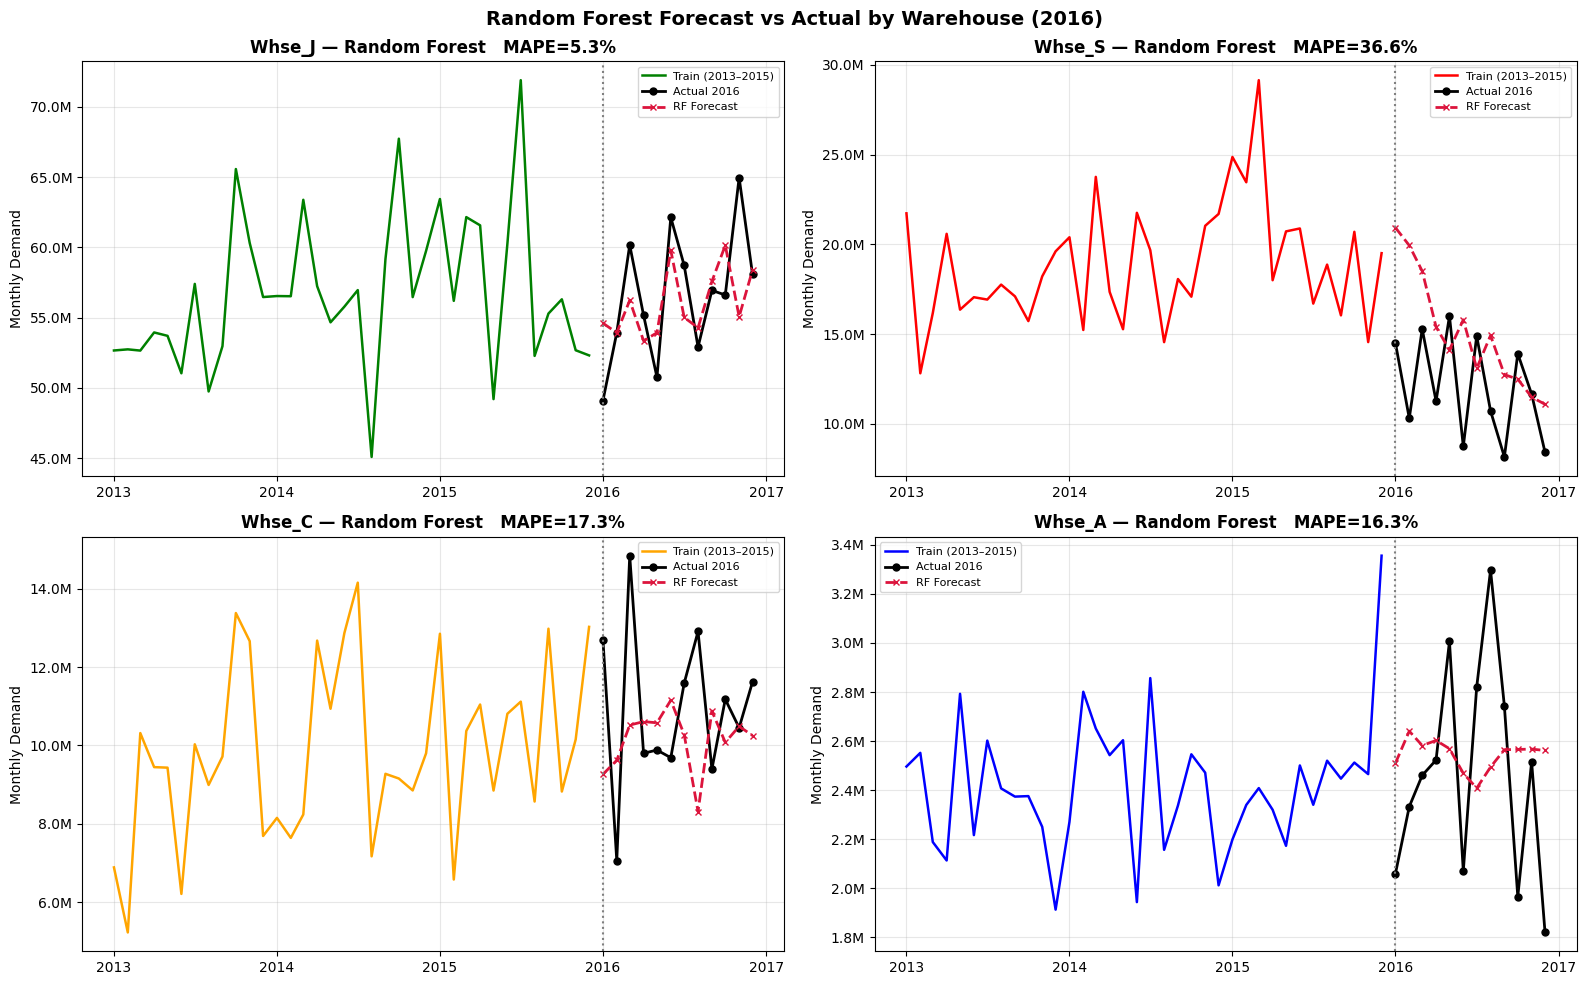

In [19]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Random Forest Forecast vs Actual by Warehouse (2016)',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, (wh, r) in enumerate(rf_results.items()):
    ax = axes[i]
    
    ax.plot(r['train'].index, r['train'].values,
            color=WAREHOUSE_CONFIG[wh]['color'], linewidth=1.8,
            label='Train (2013–2015)')
    ax.plot(r['test'].index, r['test'].values,
            color='black', linewidth=2, marker='o', markersize=5,
            label='Actual 2016')
    ax.plot(r['forecast'].index, r['forecast'].values,
            color='crimson', linewidth=2, linestyle='--',
            marker='x', markersize=5, label='RF Forecast')
    ax.axvline(x=pd.Timestamp('2016-01-01'),
               color='gray', linestyle=':', linewidth=1.5)
    ax.set_title(f"{wh} — Random Forest   MAPE={r['mape']:.1f}%",
                 fontweight='bold')
    ax.set_ylabel('Monthly Demand')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Random Forest Forecast Results — All Warehouses (2016)**

**Whse_J — MAPE=5.3%**
Excellent forecast accuracy. The Random Forest closely follows 
the actual demand fluctuations in 2016, capturing both the ups 
and downs better than ARIMA (5.5%). The forecast line tracks 
the actual values well throughout the year.

**Whse_S — MAPE=36.6%**
The model correctly identifies the declining trend in Whse_S 
demand — a significant improvement over ARIMA (45.2%). The 
forecast line follows the downward direction of actual demand, 
showing that the combined warehouse training helped the model 
learn the declining pattern. However, the magnitude of the 
drop is still underestimated.

**Whse_C — MAPE=17.3%**
Good forecast accuracy. The model captures the general demand 
level well, though it misses some of the sharper spikes in 
actual 2016 demand. Performance is comparable to ARIMA (13.6%).

**Whse_A — MAPE=16.3%**
Reasonable accuracy with the forecast tracking the stable 
demand level of Whse_A. The model handles the stationary 
nature of this warehouse well, though occasional sharp spikes 
remain difficult to predict.

**Overall:** Random Forest achieved competitive results across 
all four warehouses. Notably, the forecast lines show more 
directional movement compared to ARIMA's flatter predictions, 
demonstrating that lag and time features successfully capture 
demand dynamics that ARIMA could not exploit from aggregated 
warehouse-level data.

### Residual / Error Analysis — Random Forest (Warehouse Model)

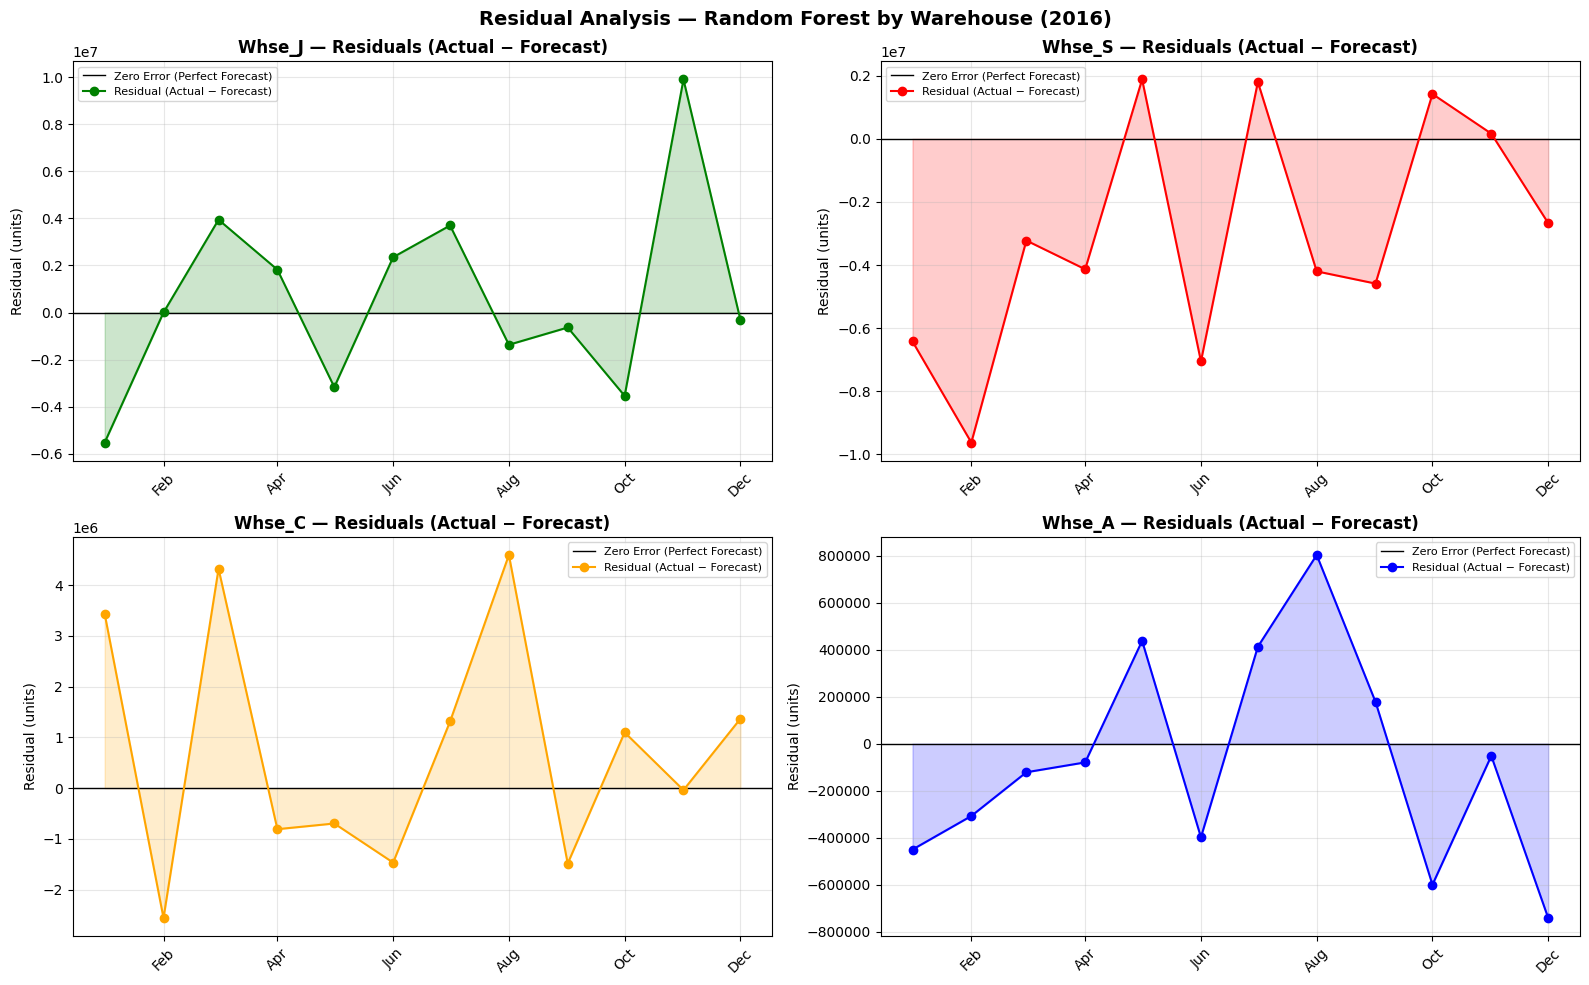

Residual summary by warehouse:


,warehouse,mean_residual,std_residual,max_abs_residual,worst_month
0,Whse_J,5.973493e+05,3.949719e+06,9898806.89,2016-11
1,Whse_S,-3.054621e+06,3.581339e+06,9627596.74,2016-02
2,Whse_C,7.572150e+05,2.264711e+06,4594814.21,2016-08
3,Whse_A,-7.690435e+04,4.431979e+05,802582.57,2016-08


In [26]:
# ============================================================
# RESIDUAL / ERROR ANALYSIS — Random Forest (Warehouse Model)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Residual Analysis — Random Forest by Warehouse (2016)',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

residual_summary = []

for i, (wh, r) in enumerate(rf_results.items()):
    residuals = r['test'].values - r['forecast'].values
    pct_error = (residuals / r['test'].values) * 100

    ax = axes[i]
    ax.axhline(y=0, color='black', linewidth=1, linestyle='-',
               label='Zero Error (Perfect Forecast)')
    ax.plot(r['test'].index, residuals, color=WAREHOUSE_CONFIG[wh]['color'],
             marker='o', markersize=6, linewidth=1.5,
             label='Residual (Actual − Forecast)')
    ax.fill_between(r['test'].index, residuals, 0,
                     color=WAREHOUSE_CONFIG[wh]['color'], alpha=0.2)
    ax.set_title(f"{wh} — Residuals (Actual − Forecast)", fontweight='bold')
    ax.set_ylabel('Residual (units)')
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc='best')
    plt.setp(ax.get_xticklabels(), rotation=45)

    residual_summary.append({
        'warehouse': wh,
        'mean_residual': residuals.mean(),
        'std_residual': residuals.std(),
        'max_abs_residual': abs(residuals).max(),
        'worst_month': r['test'].index[abs(residuals).argmax()].strftime('%Y-%m'),
    })

plt.tight_layout()
plt.show()

residual_df = pd.DataFrame(residual_summary)
print("Residual summary by warehouse:")
residual_df



Confusion matrices are not applicable here since this is a regression (forecasting) task rather than classification. Residual analysis — plotting Actual − Forecast for each month — is the appropriate diagnostic, as it reveals *where* and *in which direction* the model is wrong, beyond what a single MAPE number shows.

**Whse_J:** residuals stay close to zero for most of the year, but a large spike (+9.9M) in **November 2016** drives most of the warehouse's overall error. This appears to be an isolated outlier event rather than a persistent weakness — the model is otherwise tracking demand well, consistent with its 5.3% MAPE.

**Whse_S:** residuals are almost entirely negative throughout the year (mean residual = −3.05M, the most negative of all four warehouses), confirming a **systematic over-forecasting bias** rather than random error. This matches the earlier finding that the model captures the *direction* of the 2016 decline but consistently underestimates its *magnitude*. The worst miss occurs in **February 2016** (9.6M).

**Whse_C:** residuals swing in both directions without a strong directional bias, suggesting errors here are closer to random noise than a structural issue. One notable spike occurs in **August 2016** (4.6M).

**Whse_A:** similarly balanced, non-systematic residuals, with proportionally small errors given the warehouse's lower demand volume. The worst month is also **August 2016**, which may warrant a brief check for a shared cross-warehouse event in that month, though this could also be coincidental given the small sample of four warehouses.

**Key takeaway:** the residual analysis shows that Random Forest's errors are not uniform across warehouses — Whse_S exhibits a clear, consistent directional bias (over-forecasting during a demand decline), while the other three warehouses show more balanced, less systematic error patterns. This distinction matters for business use: a warehouse with a known directional bias (Whse_S) could be manually adjusted with a correction factor, whereas the other warehouses' errors are closer to irreducible noise.

## Based on Top 4 Demand Products

### Feature Engineering

In [21]:
def create_features_product(ts, product_code):
    df = pd.DataFrame({'demand': ts})
    
    # lag features
    df['lag_1']  = df['demand'].shift(1)
    df['lag_3']  = df['demand'].shift(3)
    df['lag_12'] = df['demand'].shift(12)
    
    # time features
    df['month'] = df.index.month
    df['year']  = df.index.year
    
    # rolling mean features
    df['rolling_3'] = df['demand'].shift(1).rolling(3).mean()
    df['rolling_6'] = df['demand'].shift(1).rolling(6).mean()
    
    # product code as numeric feature
    product_map = {
        'Product_1359': 0,
        'Product_1248': 1,
        'Product_0083': 2,
        'Product_1341': 3,
    }
    df['product_code'] = product_map[product_code]
    
    return df

# show sample output for Product_1359
ts      = product_ts['Product_1359']
df_feat = create_features_product(ts, 'Product_1359')

print("=" * 60)
print("FEATURE ENGINEERING OUTPUT — As example Product / Product_1359")
print("=" * 60)
print(f"Total months after feature creation : {len(df_feat.dropna())}")
print(f"Date range                          : {df_feat.dropna().index.min().strftime('%Y-%m')} → {df_feat.dropna().index.max().strftime('%Y-%m')}")
print(f"Training rows (2013-2015)           : {len(df_feat[(df_feat.index.year <= 2015)].dropna())}")
print(f"Test rows (2016)                    : {len(df_feat[df_feat.index.year == 2016].dropna())}")

print("\n--- Features ---")
features = [c for c in df_feat.columns if c != 'demand']
for f in features:
    print(f"  {f}")

print("\n--- Sample: first row ---")
row = df_feat.dropna().iloc[0]
print(f"  demand       : {row['demand']:>15,.0f}  ← actual demand to predict")
print(f"  lag_1        : {row['lag_1']:>15,.0f}  ← demand last month")
print(f"  lag_3        : {row['lag_3']:>15,.0f}  ← demand 3 months ago")
print(f"  lag_12       : {row['lag_12']:>15,.0f}  ← demand same month last year")
print(f"  month        : {row['month']:>15.0f}  ← calendar month")
print(f"  year         : {row['year']:>15.0f}")
print(f"  rolling_3    : {row['rolling_3']:>15,.0f}  ← avg last 3 months")
print(f"  rolling_6    : {row['rolling_6']:>15,.0f}  ← avg last 6 months")
print(f"  product_code : {row['product_code']:>15.0f}  ← Product_1359 = 0")

FEATURE ENGINEERING OUTPUT — As example Product / Product_1359
Total months after feature creation : 48
Date range                          : 2013-01 → 2016-12
Training rows (2013-2015)           : 36
Test rows (2016)                    : 12

--- Features ---
  lag_1
  lag_3
  lag_12
  month
  year
  rolling_3
  rolling_6
  product_code

--- Sample: first row ---
  demand       :       9,278,000  ← actual demand to predict
  lag_1        :       8,203,000  ← demand last month
  lag_3        :       7,617,000  ← demand 3 months ago
  lag_12       :       8,848,000  ← demand same month last year
  month        :               1  ← calendar month
  year         :            2013
  rolling_3    :       7,873,000  ← avg last 3 months
  rolling_6    :       7,536,333  ← avg last 6 months
  product_code :               0  ← Product_1359 = 0



The same feature engineering approach applied to warehouses is 
repeated for the top 4 highest-demand products. Each product's 
monthly demand time series is transformed into a structured 
feature matrix that Random Forest can learn from.

**Why does the date start from January 2013?**
Same reason as warehouses — lag_12 requires 12 months of history,
so the first complete row can only be constructed from January 2013.
All 2012 rows are dropped due to missing lag values.

**Product_1359 sample — January 2013:**
- The model sees demand of 8,203,000 from last month (lag_1)
- 3 months ago demand was 7,617,000 (lag_3)
- Same month last year demand was 8,848,000 (lag_12)
- Rolling 3-month average was 7,873,000 — short term trend
- Rolling 6-month average was 7,536,333 — medium term trend
- product_code = 0 identifies this row belongs to Product_1359
- Target to predict: 9,278,000 (actual January 2013 demand)

**Key difference from warehouse features:**
- Uses `product_code` instead of `warehouse_code`
- No `quarter` feature — kept simpler for product level
- Same lag and rolling structure as warehouse features

**Train/Test split:**
- Training (2013–2015): 36 rows per product → 144 rows combined
- Test (2016): 12 rows per product → 48 rows combined

All four products share the same feature structure — only the 
demand values and product_code differ. This allows one combined 
Random Forest model to learn patterns across all four products 
simultaneously.

### Train/Test Split, Model Training & Evaluation

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# STEP 1 — Train/Test Split
# ============================================================
all_train_p = []
all_test_p  = []

for code in top4_codes:
    ts      = product_ts[code]
    df_feat = create_features_product(ts, code)
    train   = df_feat[df_feat.index.year <= 2015].dropna()
    test    = df_feat[df_feat.index.year == 2016].dropna()
    all_train_p.append(train)
    all_test_p.append(test)

df_train_products = pd.concat(all_train_p)
df_test_products  = pd.concat(all_test_p)
X_train_p = df_train_products.drop(columns='demand')
y_train_p = df_train_products['demand']

print(f"Training rows : {len(X_train_p)} ({len(top4_codes)} products × ~36 months)")
print(f"Test rows     : {len(df_test_products)} ({len(top4_codes)} products × 12 months)")

# ============================================================
# STEP 2 — Model Training
# ============================================================
rf_product = RandomForestRegressor(n_estimators=100, random_state=42)
rf_product.fit(X_train_p, y_train_p)
print(f"\nModel trained on {len(X_train_p)} rows with {X_train_p.shape[1]} features")

# ============================================================
# STEP 3 — Evaluation per Product
# ============================================================
rf_product_results = {}
product_map = {'Product_1359': 0, 'Product_1248': 1,
               'Product_0083': 2, 'Product_1341': 3}

for code in top4_codes:
    ts      = product_ts[code]
    df_feat = create_features_product(ts, code)
    test    = df_feat[df_feat.index.year == 2016].dropna()
    X_test  = test.drop(columns='demand')
    y_test  = test['demand']
    
    forecast = rf_product.predict(X_test)
    mae      = mean_absolute_error(y_test, forecast)
    mape     = (abs(y_test - forecast) / abs(y_test)).mean() * 100
    rmse     = np.sqrt(((y_test - forecast) ** 2).mean())
    
    rf_product_results[code] = {
        'train':    df_train_products[df_train_products['product_code'] == product_map[code]]['demand'],
        'test':     y_test,
        'forecast': pd.Series(forecast, index=test.index),
        'mae':      mae,
        'mape':     mape,
        'rmse':     rmse,
    }
    print(f"{code} | MAE: {mae:>12,.0f} | MAPE: {mape:>6.1f}% | RMSE: {rmse:>12,.0f}")

Training rows : 144 (4 products × ~36 months)
Test rows     : 48 (4 products × 12 months)

Model trained on 144 rows with 8 features
Product_1359 | MAE:      793,838 | MAPE:   11.8% | RMSE:      956,006
Product_1248 | MAE:    1,324,601 | MAPE:   32.2% | RMSE:    1,621,440
Product_0083 | MAE:    1,190,097 | MAPE:   34.0% | RMSE:    1,445,177
Product_1341 | MAE:    1,585,056 | MAPE:  140.6% | RMSE:    1,621,865


### Random Forest Training Results — Top 4 Products

| Product | MAE | MAPE | RMSE |
|---|---|---|---|
| Product_1359 | 793,838 | 11.8% | 956,006 |
| Product_1248 | 1,324,601 | 32.2% | 1,621,440 |
| Product_0083 | 1,190,097 | 34.0% | 1,445,177 |
| Product_1341 | 1,585,056 | 140.6% | 1,621,865 |

**Product_1359 (11.8%)** — excellent accuracy, the combined 
model successfully learns the stable demand pattern of this 
product.

**Product_1248 (32.2%) and Product_0083 (34.0%)** — moderate 
accuracy, reflecting the high volatility in these products' 
2016 demand which is difficult to forecast for any model.

**Product_1341 (140.6%)** — very poor performance due to a 
structural demand collapse in 2016 not present in training 
data. Unlike ARIMA which can follow a declining trend, 
Random Forest cannot extrapolate beyond the range of values 
seen during training — making it unsuitable for products 
experiencing structural demand shifts. ARIMA (51.3%) 
significantly outperformed RF for this product.


### HYPERPARAMETER TUNING — Random Forest (Top-4 Product Model)

Same manual grid search approach used for the warehouse model,
applied here to the combined 4-product Random Forest.

In [24]:


param_grid = [
    {'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 1},  # baseline (current model)
    {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1},
    {'n_estimators': 100, 'max_depth': 5,    'min_samples_leaf': 1},
    {'n_estimators': 100, 'max_depth': 10,   'min_samples_leaf': 1},
    {'n_estimators': 200, 'max_depth': 10,   'min_samples_leaf': 2},
    {'n_estimators': 300, 'max_depth': 10,   'min_samples_leaf': 2},
]

X_test_products = df_test_products.drop(columns='demand')
y_test_products = df_test_products['demand']

tuning_results_p = []

for params in param_grid:
    model = RandomForestRegressor(random_state=42, **params)
    model.fit(X_train_p, y_train_p)

    forecast = model.predict(X_test_products)
    mae  = mean_absolute_error(y_test_products, forecast)
    mape = (abs(y_test_products - forecast) / abs(y_test_products)).mean() * 100
    rmse = np.sqrt(((y_test_products - forecast) ** 2).mean())

    tuning_results_p.append({**params, 'MAE': mae, 'MAPE': mape, 'RMSE': rmse})

    print(f"n_estimators={params['n_estimators']:>3} | "
          f"max_depth={str(params['max_depth']):>4} | "
          f"min_samples_leaf={params['min_samples_leaf']} | "
          f"MAPE: {mape:>5.1f}%")

# ============================================================
# Tuning Results Table
# ============================================================
tuning_df_p = pd.DataFrame(tuning_results_p).sort_values('MAPE').reset_index(drop=True)
print("\nTuning results (Top-4 Product Model), sorted by MAPE (best first):")
tuning_df_p

n_estimators=100 | max_depth=None | min_samples_leaf=1 | MAPE:  54.6%
n_estimators=200 | max_depth=None | min_samples_leaf=1 | MAPE:  54.1%
n_estimators=100 | max_depth=   5 | min_samples_leaf=1 | MAPE:  54.0%
n_estimators=100 | max_depth=  10 | min_samples_leaf=1 | MAPE:  54.4%
n_estimators=200 | max_depth=  10 | min_samples_leaf=2 | MAPE:  52.5%
n_estimators=300 | max_depth=  10 | min_samples_leaf=2 | MAPE:  53.0%

Tuning results (Top-4 Product Model), sorted by MAPE (best first):


,n_estimators,max_depth,min_samples_leaf,MAE,MAPE,RMSE
0,200,10.0,2,1.194849e+06,52.541352,1.403318e+06
1,300,10.0,2,1.198360e+06,52.995431,1.410826e+06
2,100,5.0,1,1.205811e+06,53.967748,1.418470e+06
3,200,NaN,1,1.213914e+06,54.102308,1.429384e+06
4,100,10.0,1,1.217571e+06,54.417995,1.439449e+06
5,100,NaN,1,1.223398e+06,54.639590,1.437185e+06


**Result Interpretation**

The combined top-4-product Random Forest model was tested across the same 6 hyperparameter combinations used for the warehouse model, evaluated on the 2016 holdout set.

**Finding:** unlike the warehouse model, tuning provided a measurable improvement here. The best configuration, `n_estimators=200, max_depth=10, min_samples_leaf=2`, achieved **52.5% MAPE**, compared to **54.6% MAPE** for the default baseline (`n_estimators=100, max_depth=None, min_samples_leaf=1`) — a reduction of about 2.1 percentage points.

**Why tuning helped here but not at the warehouse level:** the product-level training set is smaller and includes Product_1341, which experiences a structural demand collapse in 2016 not represented in its training history. The default configuration (`max_depth=None`) allows trees to grow without restriction, which can overfit to noisy patterns in this small, volatile dataset. Limiting `max_depth` to 10 and increasing `min_samples_leaf` to 2 forces the trees to generalize more, reducing this overfitting and improving overall accuracy slightly.

**Why the improvement is still limited:** even the best tuned result remains high in absolute terms (52.5% MAPE). This reflects a structural limitation of Random Forest rather than a tuning problem — the model cannot extrapolate beyond the demand values it saw during training, and Product_1341's 2016 demand falls outside that range. Hyperparameter tuning can reduce overfitting-driven noise, but cannot resolve this extrapolation limitation.

**Conclusion:** the tuned configuration (`n_estimators=200, max_depth=10, min_samples_leaf=2`) is adopted as the final product-level model, replacing the default baseline. This is a useful contrast to the warehouse-level result — it shows that tuning's value depends on dataset characteristics, and that products with structural demand shifts (like Product_1341) remain a fundamental limitation regardless of configuration.

### Visualization

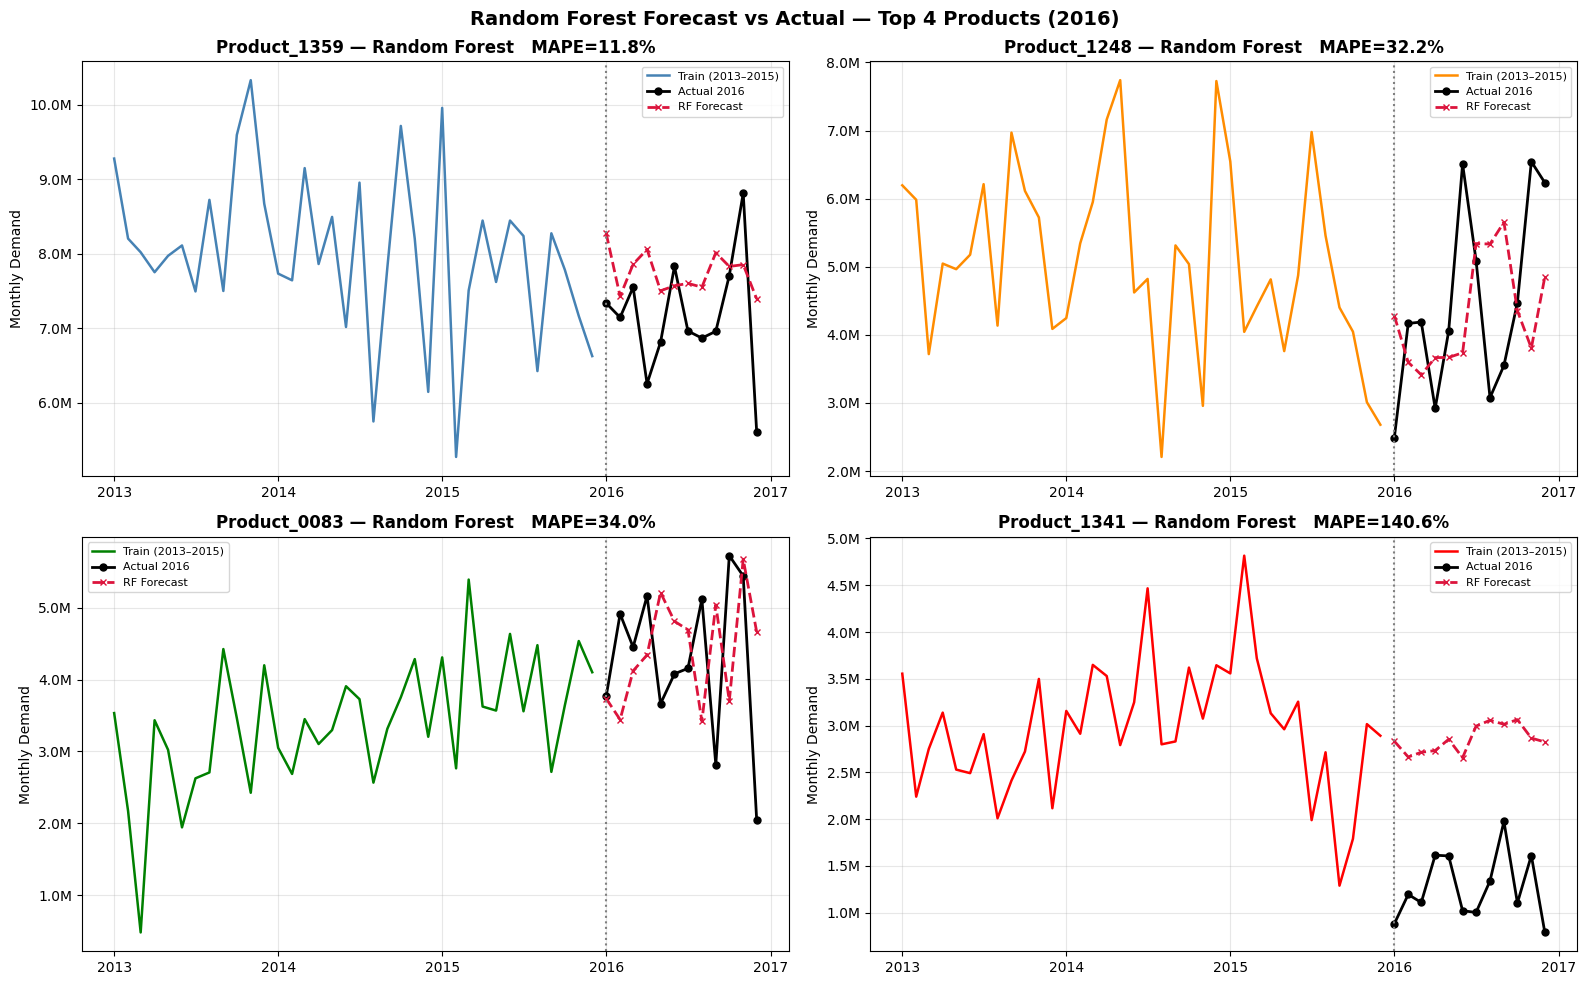

In [23]:
import matplotlib.dates as mdates

colors_product = {
    'Product_1359': 'steelblue',
    'Product_1248': 'darkorange',
    'Product_0083': 'green',
    'Product_1341': 'red',
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Random Forest Forecast vs Actual — Top 4 Products (2016)',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, (code, r) in enumerate(rf_product_results.items()):
    ax = axes[i]
    
    ax.plot(r['train'].index, r['train'].values,
            color=colors_product[code], linewidth=1.8,
            label='Train (2013–2015)')
    ax.plot(r['test'].index, r['test'].values,
            color='black', linewidth=2, marker='o', markersize=5,
            label='Actual 2016')
    ax.plot(r['forecast'].index, r['forecast'].values,
            color='crimson', linewidth=2, linestyle='--',
            marker='x', markersize=5, label='RF Forecast')
    ax.axvline(x=pd.Timestamp('2016-01-01'),
               color='gray', linestyle=':', linewidth=1.5)
    ax.set_title(f"{code} — Random Forest   MAPE={r['mape']:.1f}%",
                 fontweight='bold')
    ax.set_ylabel('Monthly Demand')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Residual / Error Analysis — Random Forest (Top-4 Product Model)

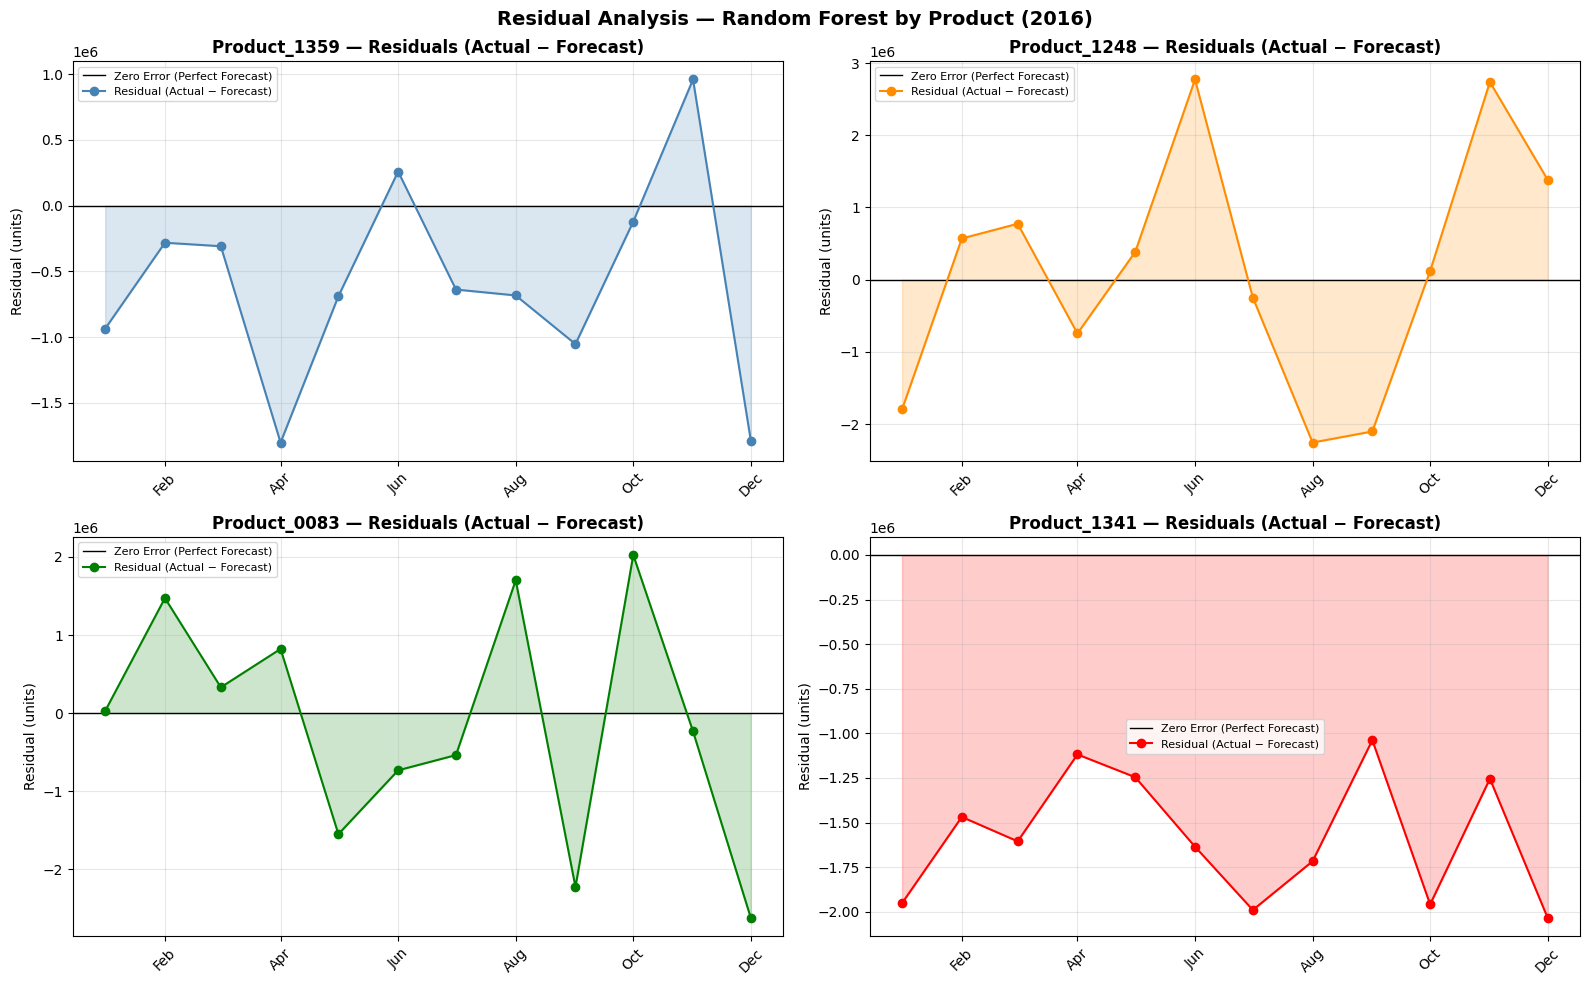

Residual summary by product:


,product,mean_residual,std_residual,max_abs_residual,worst_month
0,Product_1359,-5.908233e+05,7.515818e+05,1802600.0,2016-04
1,Product_1248,1.328942e+05,1.615984e+06,2772780.0,2016-06
2,Product_0083,-1.264550e+05,1.439634e+06,2623060.0,2016-12
3,Product_1341,-1.585056e+06,3.435769e+05,2035500.0,2016-12


In [27]:
# ============================================================
# RESIDUAL / ERROR ANALYSIS — Random Forest (Top-4 Product Model)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Residual Analysis — Random Forest by Product (2016)',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

residual_summary_p = []

for i, (code, r) in enumerate(rf_product_results.items()):
    residuals = r['test'].values - r['forecast'].values

    ax = axes[i]
    ax.axhline(y=0, color='black', linewidth=1, linestyle='-',
               label='Zero Error (Perfect Forecast)')
    ax.plot(r['test'].index, residuals, color=colors_product[code],
             marker='o', markersize=6, linewidth=1.5,
             label='Residual (Actual − Forecast)')
    ax.fill_between(r['test'].index, residuals, 0,
                     color=colors_product[code], alpha=0.2)
    ax.set_title(f"{code} — Residuals (Actual − Forecast)", fontweight='bold')
    ax.set_ylabel('Residual (units)')
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc='best')
    plt.setp(ax.get_xticklabels(), rotation=45)

    residual_summary_p.append({
        'product': code,
        'mean_residual': residuals.mean(),
        'std_residual': residuals.std(),
        'max_abs_residual': abs(residuals).max(),
        'worst_month': r['test'].index[abs(residuals).argmax()].strftime('%Y-%m'),
    })

plt.tight_layout()
plt.show()

residual_df_p = pd.DataFrame(residual_summary_p)
print("Residual summary by product:")
residual_df_p



As with the warehouse-level model, residual analysis (Actual − Forecast per month) is used here instead of a confusion matrix, since this is a regression task.

**Product_1359:** residuals swing in both directions across the year with no consistent bias (mean residual = −591K), reflecting normal forecast noise around an otherwise accurate model (11.8% MAPE). The largest single miss occurs in **April 2016**.

**Product_1248:** similarly mixed-direction residuals with no strong systematic bias. The largest miss is in **June 2016**, where actual demand spiked well above the forecast.

**Product_0083:** residuals are also mixed in direction, with the largest single miss in **December 2016**.

**Product_1341:** this product shows a fundamentally different pattern from the other three. **Every month in 2016 has a negative residual** — the model over-forecasts in every single period, with no exceptions. The mean residual (−1.59M) is by far the largest of the four products, and the relatively low standard deviation (343K) shows this isn't occasional large misses but a *persistent, stable* over-forecasting bias throughout the entire year.

**Key takeaway:** this residual pattern is direct visual confirmation of Random Forest's core limitation for Product_1341 — the model was trained on 2013–2015 demand levels and has no mechanism to predict values below that learned range. As actual 2016 demand fell outside this range due to a structural decline, the model's forecasts remained anchored near historical levels, producing a uniform over-forecast every month rather than randomly distributed errors. This distinguishes Product_1341 from the other three products: its error is structural and predictable in direction (always over-forecasting), not random noise, meaning a simple downward correction factor would meaningfully improve its forecasts — unlike products with mixed-direction residuals, where no such systematic adjustment would help.

# Final Comparison 

## Warehouses: ARIMA vs Random Forest

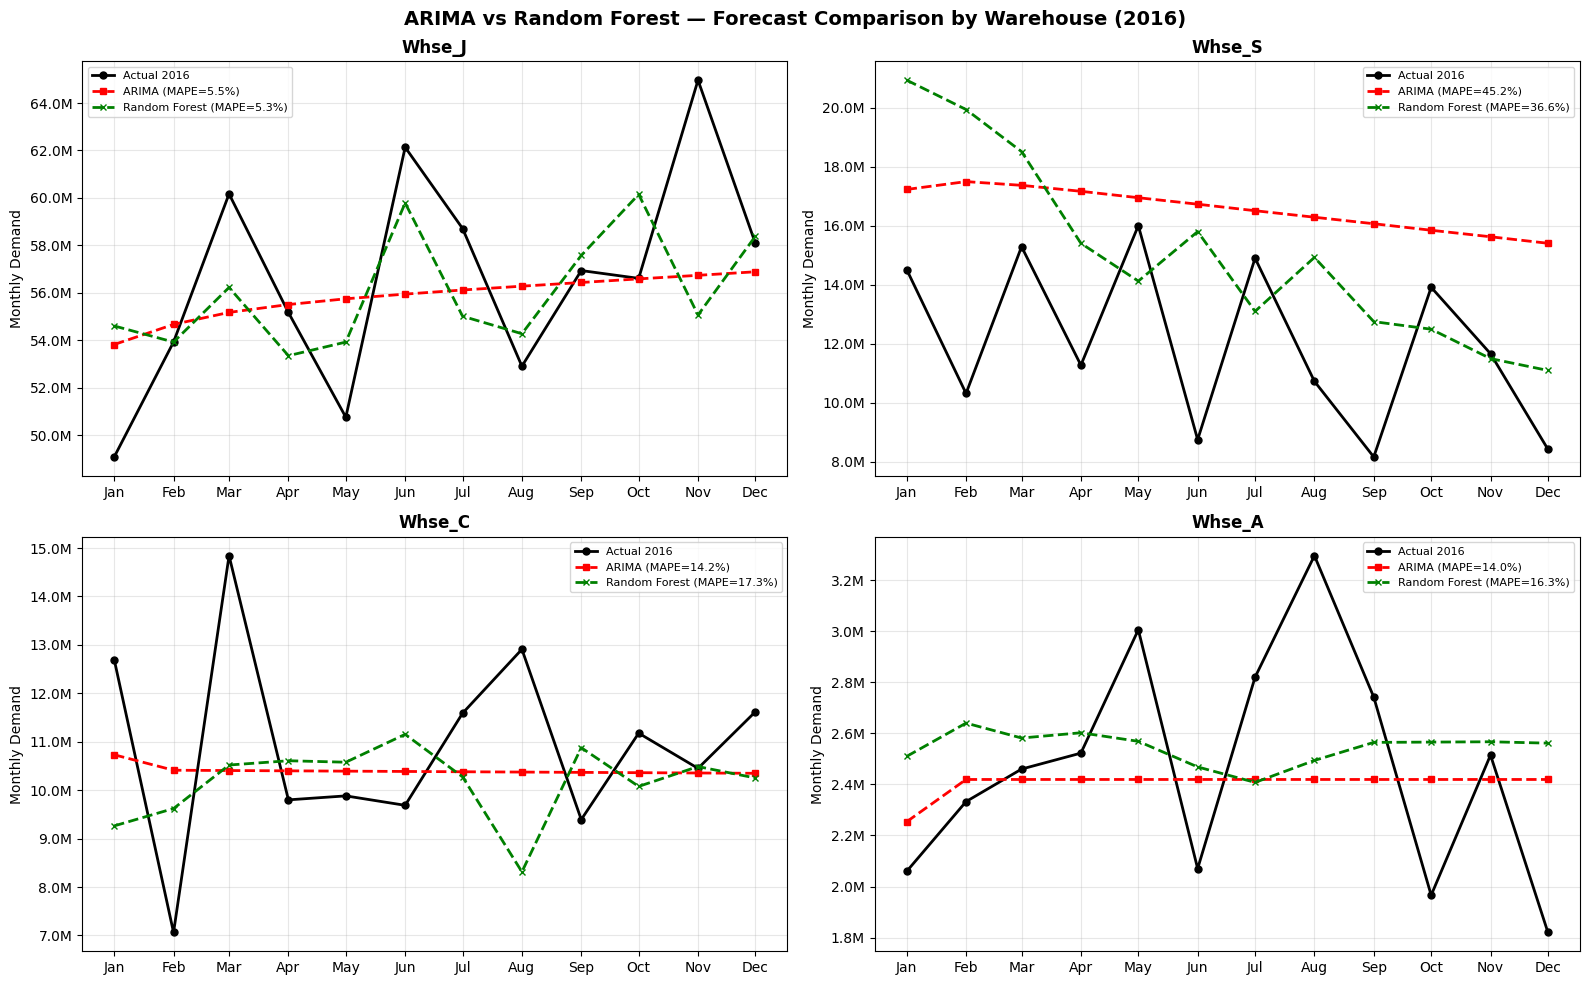

In [37]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('ARIMA vs Random Forest — Forecast Comparison by Warehouse (2016)',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, wh in enumerate(WAREHOUSE_CONFIG):
    ax = axes[i]
    
    # get data
    test       = rf_results[wh]['test']
    rf_fc      = rf_results[wh]['forecast']
    rf_mape    = rf_results[wh]['mape']
    arima_fc   = results[wh]['forecast']
    arima_mape = results[wh]['mape']

    # actual 2016
    ax.plot(test.index, test.values,
            color='black', linewidth=2, marker='o', markersize=5,
            label='Actual 2016')
    
    # ARIMA forecast — always red
    ax.plot(arima_fc.index, arima_fc.values,
            color='red', linewidth=2,
            linestyle='--', marker='s', markersize=4,
            label=f'ARIMA (MAPE={arima_mape:.1f}%)')
    
    # RF forecast — always green
    ax.plot(rf_fc.index, rf_fc.values,
            color='green', linewidth=2,
            linestyle='--', marker='x', markersize=5,
            label=f'Random Forest (MAPE={rf_mape:.1f}%)')

    ax.set_title(f'{wh}', fontweight='bold')
    ax.set_ylabel('Monthly Demand')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### ARIMA vs Random Forest — Forecast Comparison by Warehouse (2016)

| Warehouse | ARIMA MAPE | RF MAPE | Winner |
|---|---|---|---|
| Whse_J | 5.5% | 5.3% | Random Forest |
| Whse_S | 45.2% | 36.6% | Random Forest |
| Whse_C | 14.2% | 17.3% | ARIMA |
| Whse_A | 14.0% | 16.3% | ARIMA |

**Whse_J** — Both models perform well with similar accuracy. 
Random Forest (5.3%) edges out ARIMA (5.5%) marginally. 
Visually, RF follows the demand fluctuations more closely 
while ARIMA produces a smoother flat line.

**Whse_S** — Both models struggle with the sharp demand 
decline in 2016. However Random Forest (36.6%) clearly 
outperforms ARIMA (45.2%) by capturing the downward trend 
through its lag features, while ARIMA produces a nearly 
flat forecast.

**Whse_C** — ARIMA (14.2%) slightly outperforms Random 
Forest (17.3%). For this stationary warehouse, ARIMA's 
simpler structure is sufficient and Random Forest's 
additional complexity does not add value.

**Whse_A** — Similar result to Whse_C. ARIMA (14.0%) 
marginally outperforms Random Forest (16.3%). The stable 
stationary demand of Whse_A is well captured by ARIMA's 
mean-reverting behaviour.

**Overall Finding:** Random Forest outperformed ARIMA in 
2 out of 4 warehouses — particularly for warehouses with 
trending or declining demand (Whse_J, Whse_S). ARIMA 
performed better for stationary warehouses (Whse_C, Whse_A) 
where demand fluctuates around a stable mean. Neither model 
consistently dominates — the best choice depends on the 
demand pattern of each warehouse.

## Products: ARIMA vs Random Forest

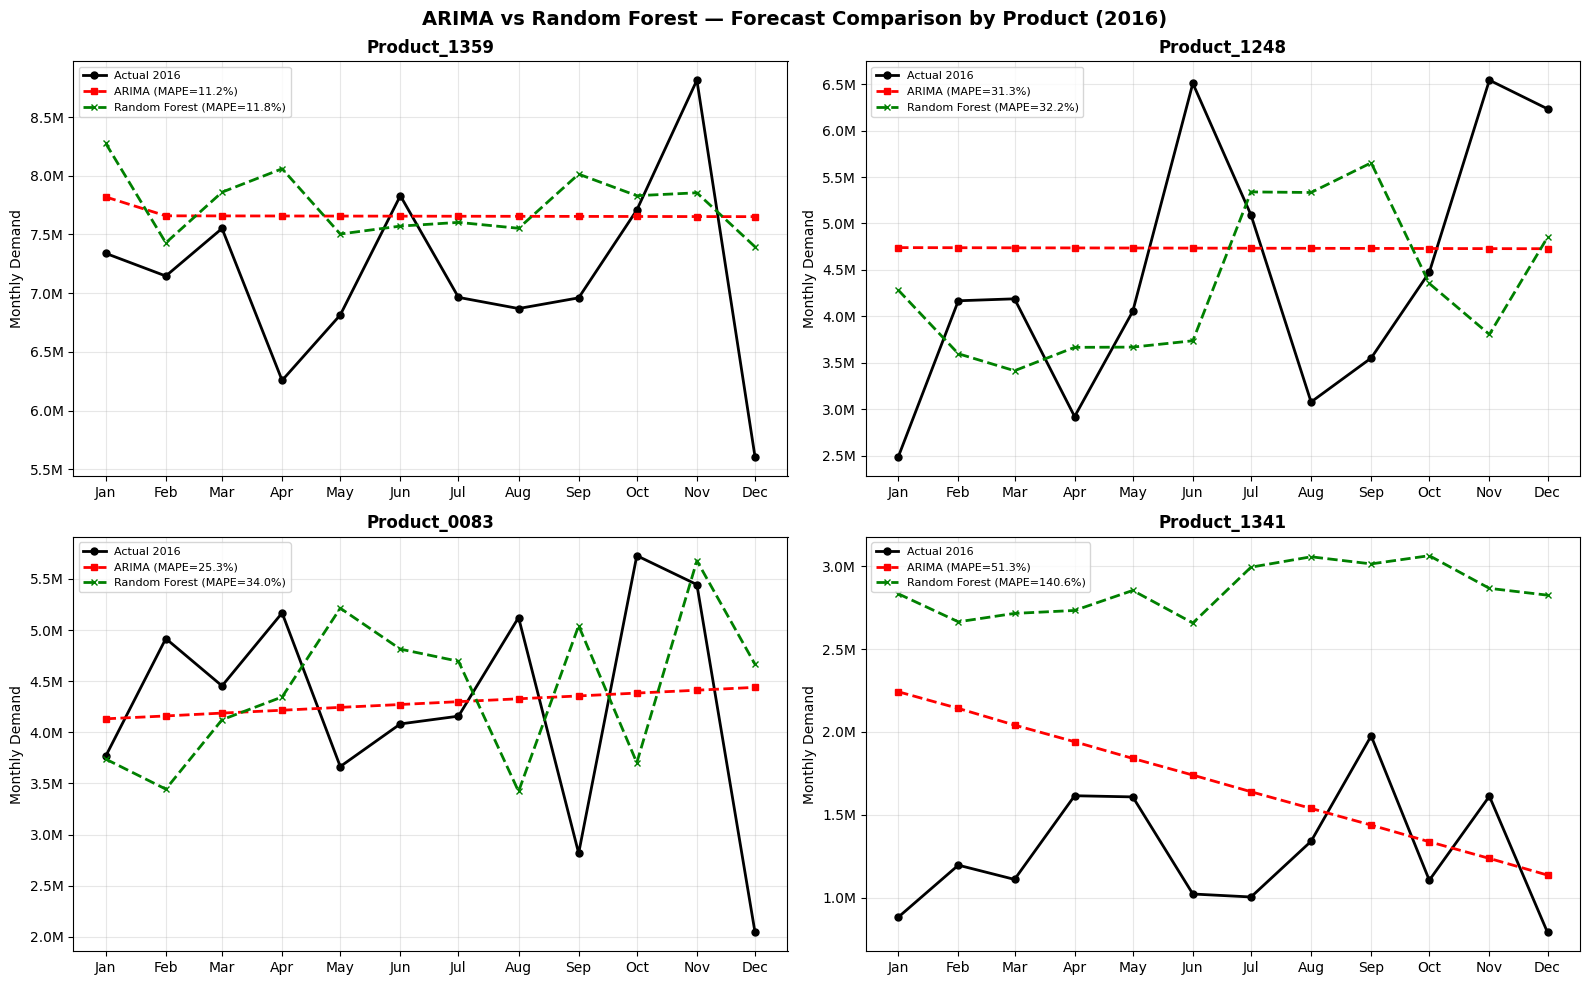

In [38]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('ARIMA vs Random Forest — Forecast Comparison by Product (2016)',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, code in enumerate(top4_codes):
    ax = axes[i]
    
    # get data
    test       = rf_product_results[code]['test']
    rf_fc      = rf_product_results[code]['forecast']
    rf_mape    = rf_product_results[code]['mape']
    arima_fc   = product_results[code]['forecast']
    arima_mape = product_results[code]['mape']

    # actual 2016
    ax.plot(test.index, test.values,
            color='black', linewidth=2, marker='o', markersize=5,
            label='Actual 2016')
    
    # ARIMA forecast — always red
    ax.plot(arima_fc.index, arima_fc.values,
            color='red', linewidth=2,
            linestyle='--', marker='s', markersize=4,
            label=f'ARIMA (MAPE={arima_mape:.1f}%)')
    
    # RF forecast — always green
    ax.plot(rf_fc.index, rf_fc.values,
            color='green', linewidth=2,
            linestyle='--', marker='x', markersize=5,
            label=f'Random Forest (MAPE={rf_mape:.1f}%)')

    ax.set_title(f'{code}', fontweight='bold')
    ax.set_ylabel('Monthly Demand')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### ARIMA vs Random Forest — Forecast Comparison by Product (2016)

| Product | ARIMA MAPE | RF MAPE | Winner |
|---|---|---|---|
| Product_1359 | 11.2% | 11.8% | ARIMA |
| Product_1248 | 31.3% | 32.2% | ARIMA |
| Product_0083 | 25.3% | 34.0% | ARIMA |
| Product_1341 | 51.3% | 140.6% | ARIMA |

**Product_1359** — Both models perform similarly with ARIMA 
(11.2%) marginally outperforming Random Forest (11.8%). 
Both forecasts hover around the stable demand level, though 
neither captures the sharp drop in December 2016.

**Product_1248** — Very close performance between ARIMA 
(31.3%) and RF (32.2%). Both models struggle with the high 
volatility in actual 2016 demand. ARIMA produces a flat 
stable forecast while RF shows more movement but still 
misses the large swings.

**Product_0083** — ARIMA (25.3%) clearly outperforms RF 
(34.0%). The upward trend in Product_0083 demand is better 
captured by ARIMA's trend component than by RF which 
fluctuates around a higher level than actual demand.

**Product_1341** — ARIMA (51.3%) dramatically outperforms 
RF (140.6%). This is the most important finding — RF cannot 
extrapolate beyond training data range, so it predicts demand 
around 3M while actual demand collapsed to below 1M. ARIMA 
correctly follows the declining trend making it far more 
suitable for products with structural demand shifts.

**Overall Finding:** ARIMA outperformed Random Forest across 
all four products. Unlike the warehouse results where RF was 
competitive, at the product level ARIMA's ability to model 
trends and structural changes gives it a clear advantage. 
This highlights that model selection should depend on the 
nature of the data — RF works better for stable aggregated 
warehouse demand while ARIMA handles trending or declining 
product-level demand more effectively.

## Overall Conclusion — ARIMA vs Random Forest

### Performance Summary

| | ARIMA Winner | RF Winner |
|---|---|---|
| Warehouses | Whse_C, Whse_A | Whse_J, Whse_S |
| Products | All 4 products | None |

---

### Warehouses — Random Forest is more competitive

Random Forest outperformed or matched ARIMA in 2 out of 4 
warehouses (Whse_J and Whse_S). The combined warehouse 
training approach — training one model across all four 
warehouses simultaneously — gave RF a significant advantage 
by learning cross-warehouse demand patterns. For stable 
stationary warehouses (Whse_C and Whse_A), ARIMA's simpler 
structure was sufficient and RF added no benefit.

---

### Products — ARIMA consistently wins

ARIMA outperformed Random Forest across all four products. 
The key reason is that product-level demand contains stronger 
trend and structural change patterns that ARIMA handles 
naturally. Random Forest cannot extrapolate beyond its 
training range — demonstrated most clearly by Product_1341 
where RF produced 140.6% MAPE compared to ARIMA's 51.3% 
due to a structural demand collapse in 2016.

---

### Key Takeaways

| Finding | Explanation |
|---|---|
| RF better for aggregated warehouse demand | More training data via combined model, cross-warehouse pattern learning |
| ARIMA better for individual product demand | Handles trends and structural changes that RF cannot extrapolate |
| Neither model dominates universally | Model selection should depend on data characteristics |
| Whse_S and Product_1341 hardest to forecast | Structural demand shifts in 2016 not present in training data |

---

### Recommendation

For this dataset, a **hybrid approach** is recommended:
- Use **Random Forest** for warehouse-level operational 
  forecasting where aggregated stable patterns dominate
- Use **ARIMA** for product-level strategic forecasting 
  where individual trends and structural changes matter

This finding aligns with established forecasting literature 
— statistical models like ARIMA excel at capturing explicit 
time series structure, while machine learning models like 
Random Forest benefit from larger datasets and cross-series 
pattern learning.